# Autoscience for Seasonal Forecasting
## A modular data-and-downscaling stack, searched automatically — demonstrated over Nigeria, Ethiopia & Kenya

*ACCORD · groundwork for an AGU Annual Meeting abstract · report generated from the analysis in `AGU-autoscience/`*

---

## The point & the goal

Making a seasonal rainfall forecast embeds **dozens of design choices** — which months to forecast, which
ocean patterns to use as predictors, raw SST fields vs. featurized indices, which calibration/downscaling
method, which models, what resolution, how far ahead. Today these are set by **convention**, fixed per
Regional Climate Outlook Forum, and rarely re-optimized per region and season.

**The thesis of this work:** our stack — **Rosetta** (one `fetch()` across NMME, C3S, CHIRPS, ERA5, ERSST)
and **DeepScale** (one interface for calibration, multi-model combination, downscaling, and cross-validated
skill) — makes every one of those choices a *swappable parameter*. That turns forecast **design** into a
**searchable** problem: a single driver can build, run, and identically score any configuration under
leave-one-year-out (LOYO) cross-validation. The goal is to lay groundwork for an AGU abstract arguing that
**agentic tooling over this stack can help diagnose *where* SST-based seasonal skill appears to exist, *why*,
and how close current dynamical forecasts come to realizing it.**

We run that loop on **three contrasting African countries**, re-pointed by a single config entry
(`AREA=nigeria|ethiopia|kenya`). It yields a **diagnostic lens** — not a law — for ordering where skill is
realized and pointing at the reasons (last section).

> **Read this report as a diagnostic framework, not a set of general conclusions.** The rankings below come
> from a *large* automated search over short (n≈24–33 yr) records and a *single* model/predictand
> configuration, so they carry real winner's-curse and sampling-noise risk. Only the strongest,
> mechanism-supported, multiplicity-surviving results (chiefly the East African OND short rains) should be
> read as robust; the rest are hypotheses. The methodological limits are laid out in full in
> [`docs/14_limitations_and_caveats.md`](docs/14_limitations_and_caveats.md) and summarized near the end.

## The abstract (in full)

> Seasonal precipitation forecasts embed dozens of design choices—target season, predictor domain, raw SST fields versus teleconnection indices, calibration method, model ensemble, downscaling technique, resolution, and lead time—usually fixed by convention and rarely re-optimized per region and season. We recast forecast design as a searchable space, enabled by two modular, xarray-native libraries: Rosetta, a federated data layer exposing NMME, C3S, CHIRPS, ERA5, and ERSST through one normalized fetch() interface, and DeepScale, a method-agnostic layer for calibration (CCA), multi-model combination, downscaling, and cross-validated verification. A shared contract lets a single driver build, run, and identically score any configuration under leave-one-year-out cross-validation—the precondition for automated, agent-driven search.
> 
> We demonstrate over Nigeria, Ethiopia, and Kenya, each re-pointed by one config entry. From observations the framework discovers each country's seasons, searches—rather than assumes—candidate predictors per season and subregion, and composites the drought-versus-flood ocean state; a config-driven harness then runs real NMME/C3S forecasts. Critically, we subject the discovered skill to multiplicity control (permutation FDR) and a held-out temporal block. The outcome is decisive: the East African October–December short rains carry genuine IOD/ENSO-driven skill (generalized ROC ≈ 0.70, positive RPSS) that survives FDR as a coherent family and strengthens out of sample; every West-African signal fails FDR; and the East African March–May long rains remain persistently low-skill. This skill shows no systematic decay out to six months' lead—the driver is itself predictable seasons ahead—and downscaling preserves it to roughly 5 km.
> 
> We present this as an automatically computed, per-region diagnostic of where SST-based seasonal skill exists and why, with verification (FDR, out-of-sample) as the deliverable that separates real signal from best-of-search noise. A modular, uniformly scored search over a purpose-built, config-portable stack is a template for agentic autoscience toward regionally optimal, high-resolution climate services.
> ---

## How it works — the autoscience search loop

Each experiment is not one forecast but a **function** from a configuration dict to a cross-validated skill
record. Because inputs (Rosetta) and methods (DeepScale) share a contract, a driver searches the space:

```
propose config {season, zone, predictor domain, index, calibration, MME, downscaling, lead}
      → Rosetta.fetch(...) → DeepScale.calibrate/downscale/ensemble(...) → skill() under LOYO
      → score, log, update belief → propose next
```

A cheap **observation-only screen** (observed SST → observed rainfall) prunes the space and sets a
**perfect-prognosis benchmark** — the skill of a *statistical* SST→rainfall mapping. Note this is an
empirical reference, **not a theoretical ceiling** on dynamical skill: a coupled model uses full evolving
fields and could in principle exceed it. The **dynamical** step (real NMME/C3S forecasts) is then compared
against that benchmark. All skill is LOYO cross-validated over n ≈ 24–33 years — read the *structure*, not
the third decimal (differences below ~0.1 GROC / ~0.4 correlation are within sampling noise), and see the
limitations section on **search multiplicity**.

In [1]:
from IPython.display import Image, display
from pathlib import Path
FIG = Path("outputs/figures")

def show(*names, width=820):
    for n in names:
        p = FIG / n
        if p.exists():
            display(Image(filename=str(p), width=width))
        else:
            print("[missing]", n)
print("figures dir:", FIG.resolve())

figures dir: /Users/emmettculhane/Desktop/ACCORD/analyses/AGU-autoscience/outputs/figures


## 1 · Discover the seasons (from data, no assumed calendar)

k-means on the observed annual cycle recovers each country's natural rainfall regimes. The three countries
are deliberately different:

- **Nigeria** — a smooth *latitude* gradient: bimodal Guinea coast (May + Oct, the "August break") →
  unimodal Sudano-Sahel (single August peak).
- **Ethiopia** — *terrain*-driven & anti-phased: a unimodal **Kiremt** highland monsoon (August) alongside a
  bimodal south (April + October, dry summer).
- **Kenya** — the canonical Greater-Horn **bimodal** pattern everywhere (MAM long rains + OND short rains).

> **Caveat (important).** These clustered zones are used here as *diagnostic context*. The forecasts
> downstream are built on simple **latitude-band means**, not the clustered zones — a limitation, most
> consequential for **Ethiopia**, where a latitude band at ~7–10°N blends the western Kiremt highlands
> (JJAS peak) with the eastern Somali/Ogaden lowlands (bimodal, dry summer) — regimes of *opposite phase*
> and sometimes opposite teleconnection sign, diluting the signal. Wiring the clustered (or gridded) zones
> into the forecast targets is a needed revision; see [`docs/14`](docs/14_limitations_and_caveats.md).

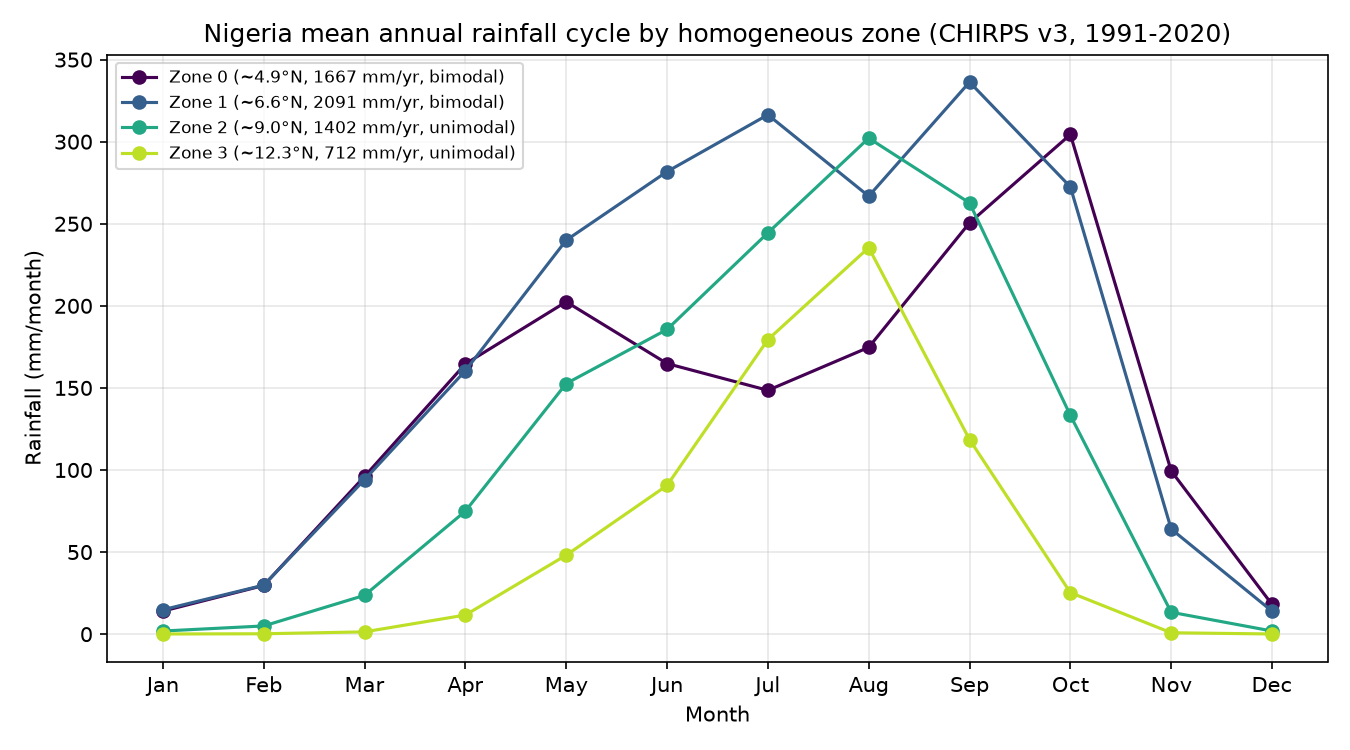

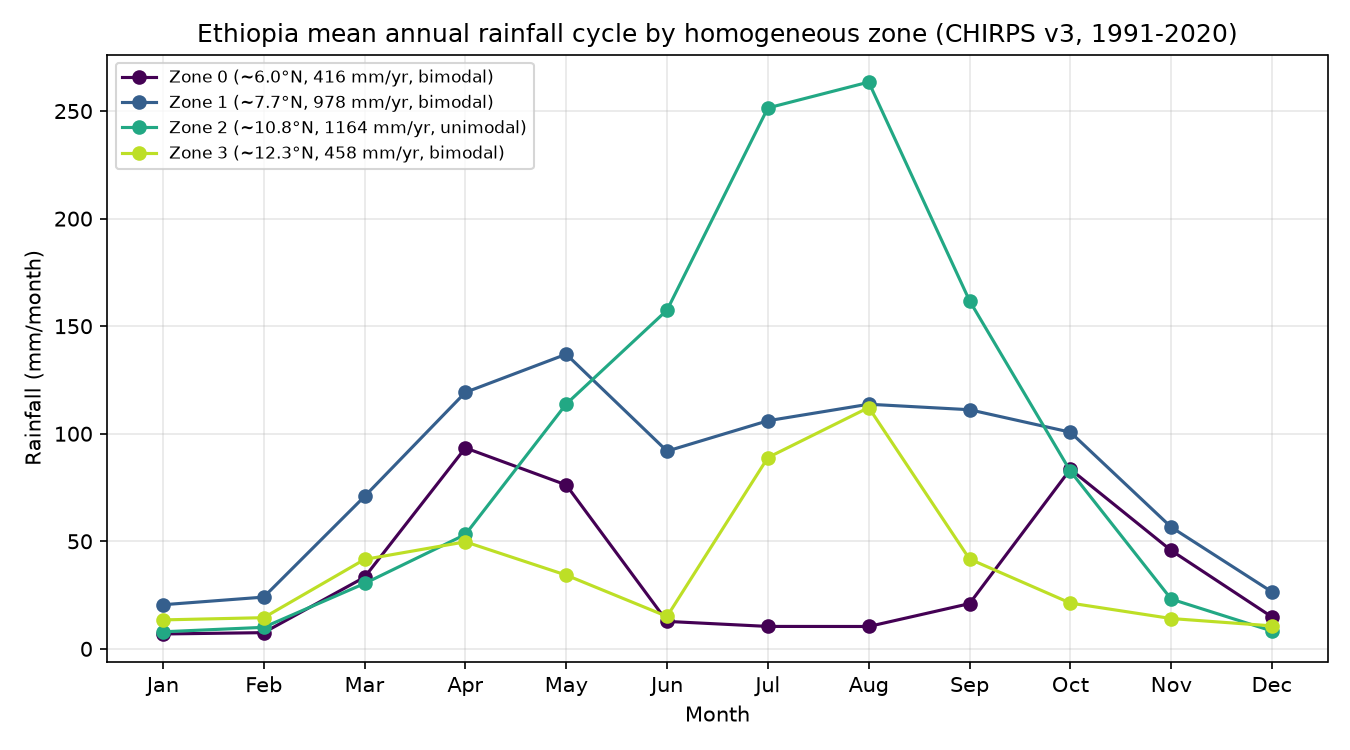

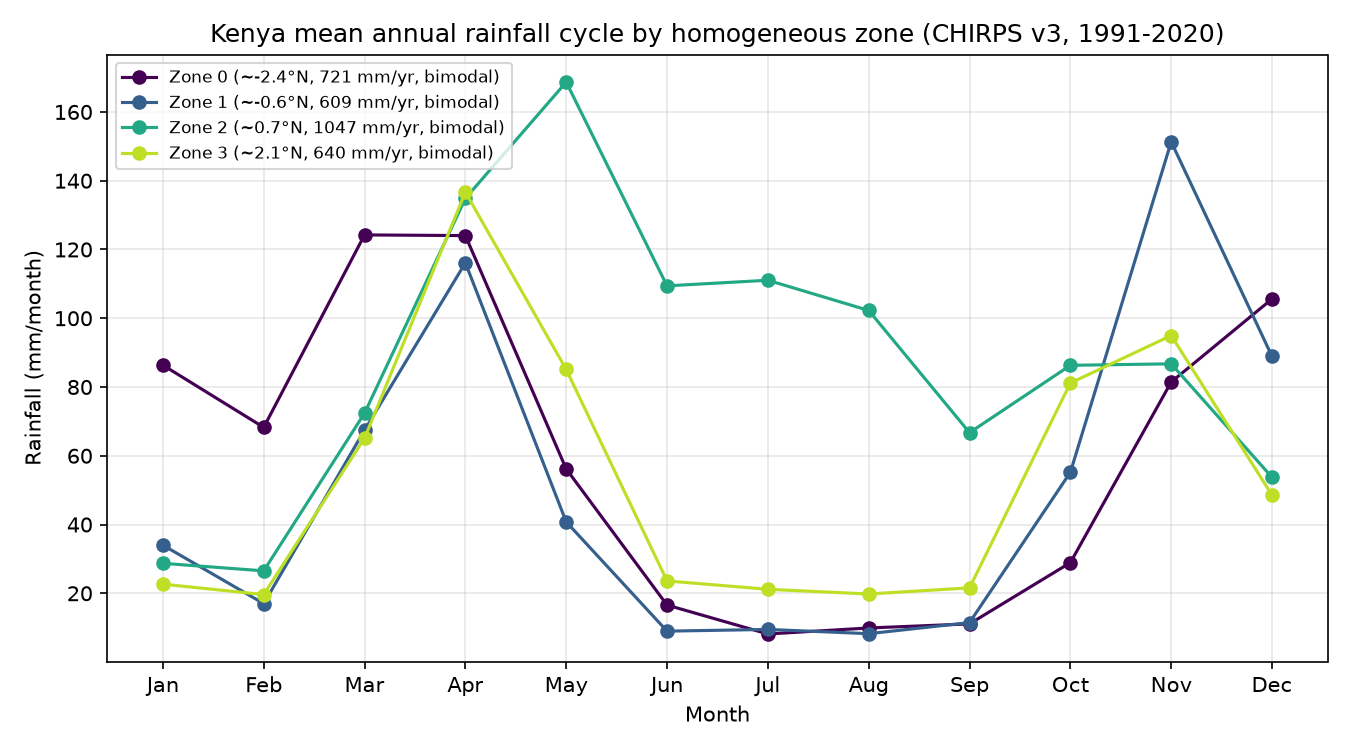

In [2]:
show('seasons_annual_cycle.png', 'seasons_annual_cycle_ethiopia.png', 'seasons_annual_cycle_kenya.png')

## 2 · Search for predictors — *the WVG contrast*

Predictor choice is **searched**, not assumed: a pool of textbook SST indices + a data-driven SST pattern +
rainfall persistence + multi-feature combos, ranked by LOYO skill per season × zone. The winner differs by
region — and the **Western-V-Gradient (WVG)**, an index Funk et al. developed for East Africa, ranks
differently in the way the literature would predict:

- it ranks **poorly for Nigeria** (Atlantic drivers dominate there), but
- ranks **near the top for Ethiopia's Kiremt** monsoon (JAS North CV corr **0.46**) and appears for Kenya's
  western JAS.

The WVG–East-Africa relationship is *already documented*, so this is a **consistency check with the
literature — a validation that the search reproduces known regional structure — rather than a new discovery**.
Below: the per-zone "recipe" for each country (best predictor per natural window). These are *best-of-search*
selections; per the limitations section, mid-ranked winners should be treated as suggestive.

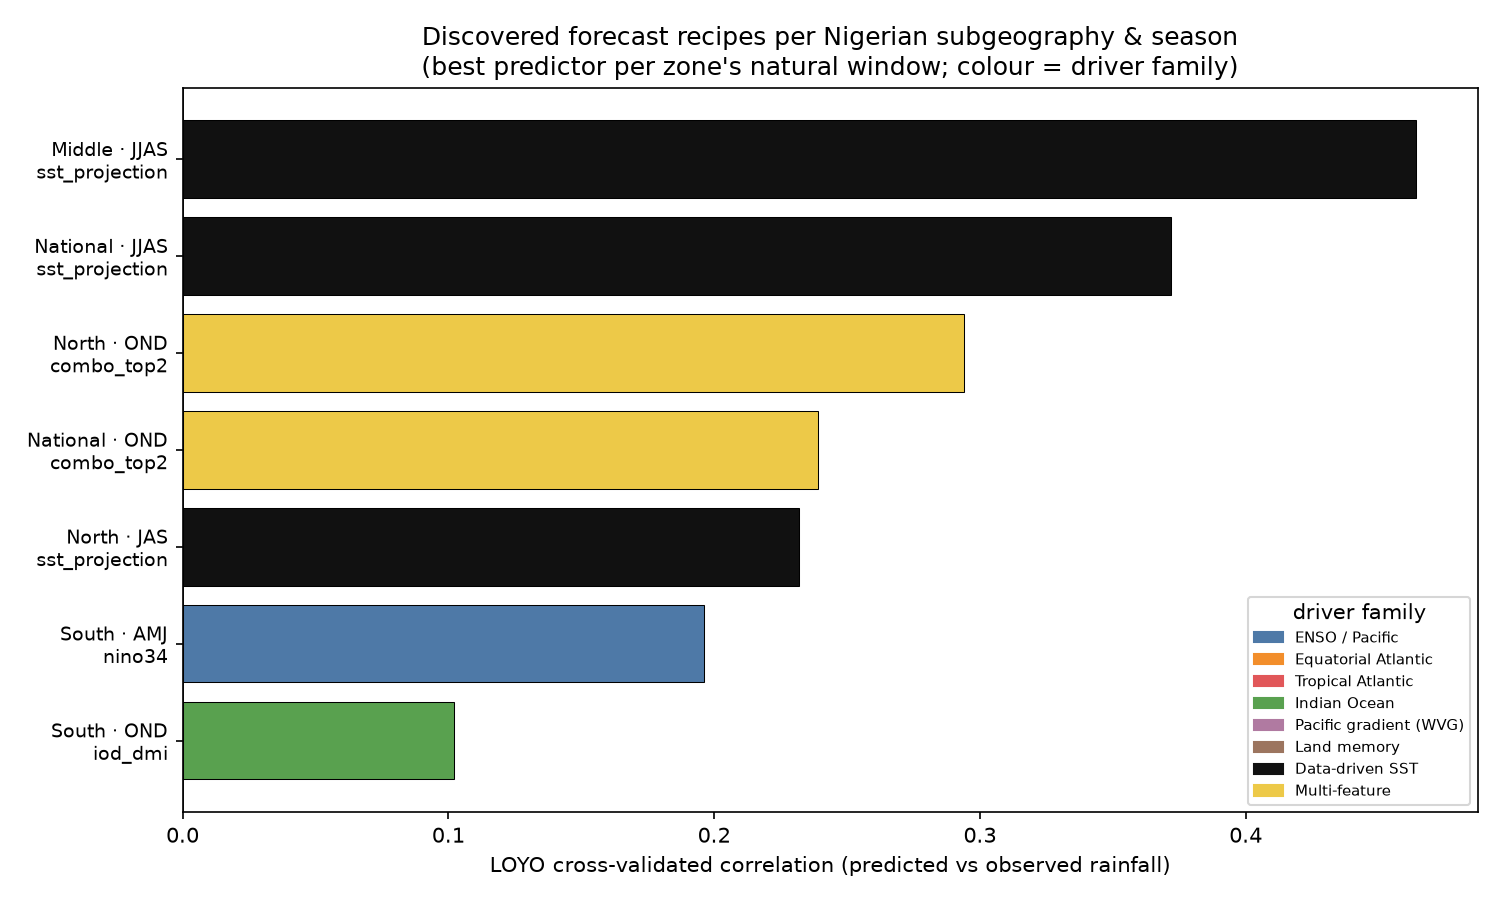

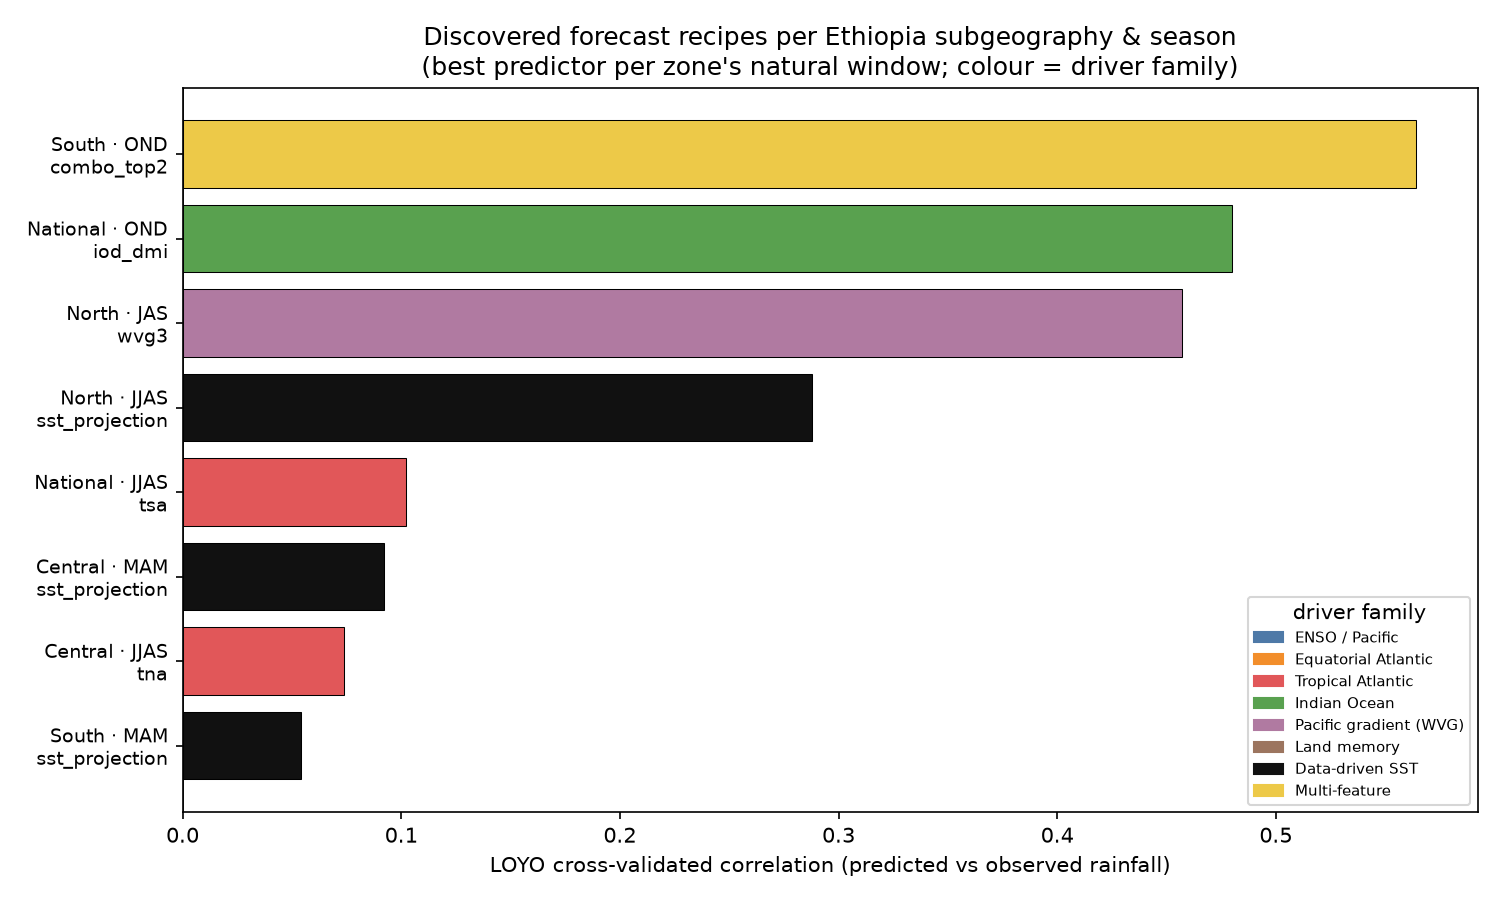

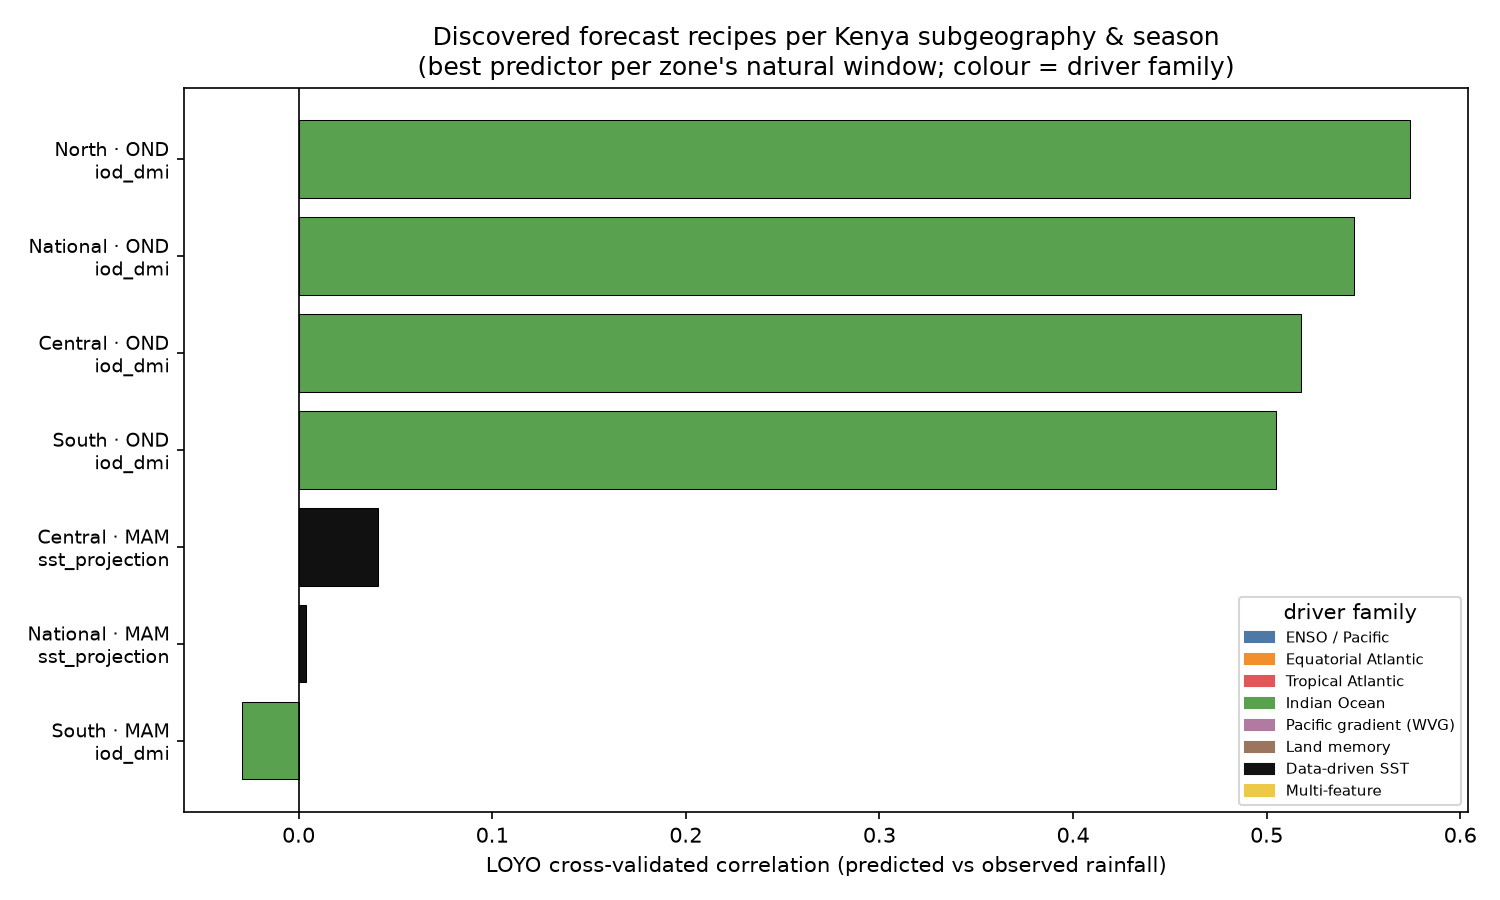

In [3]:
show('discovered_recipes.png', 'discovered_recipes_ethiopia.png', 'discovered_recipes_kenya.png')

The predictor **leaderboards** (per-cell CV skill) make the WVG contrast explicit — e.g. the northern-band
heatmaps for Nigeria vs. Ethiopia:

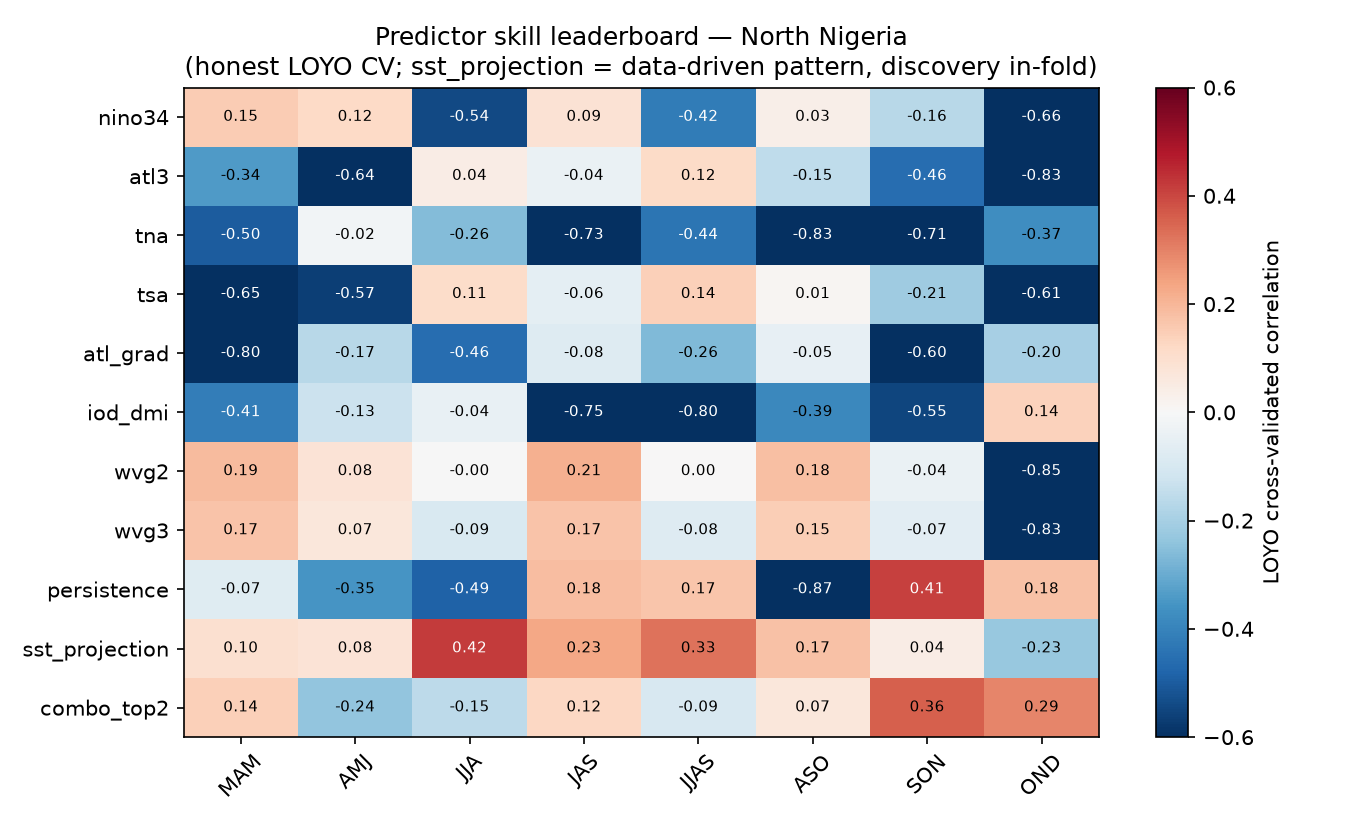

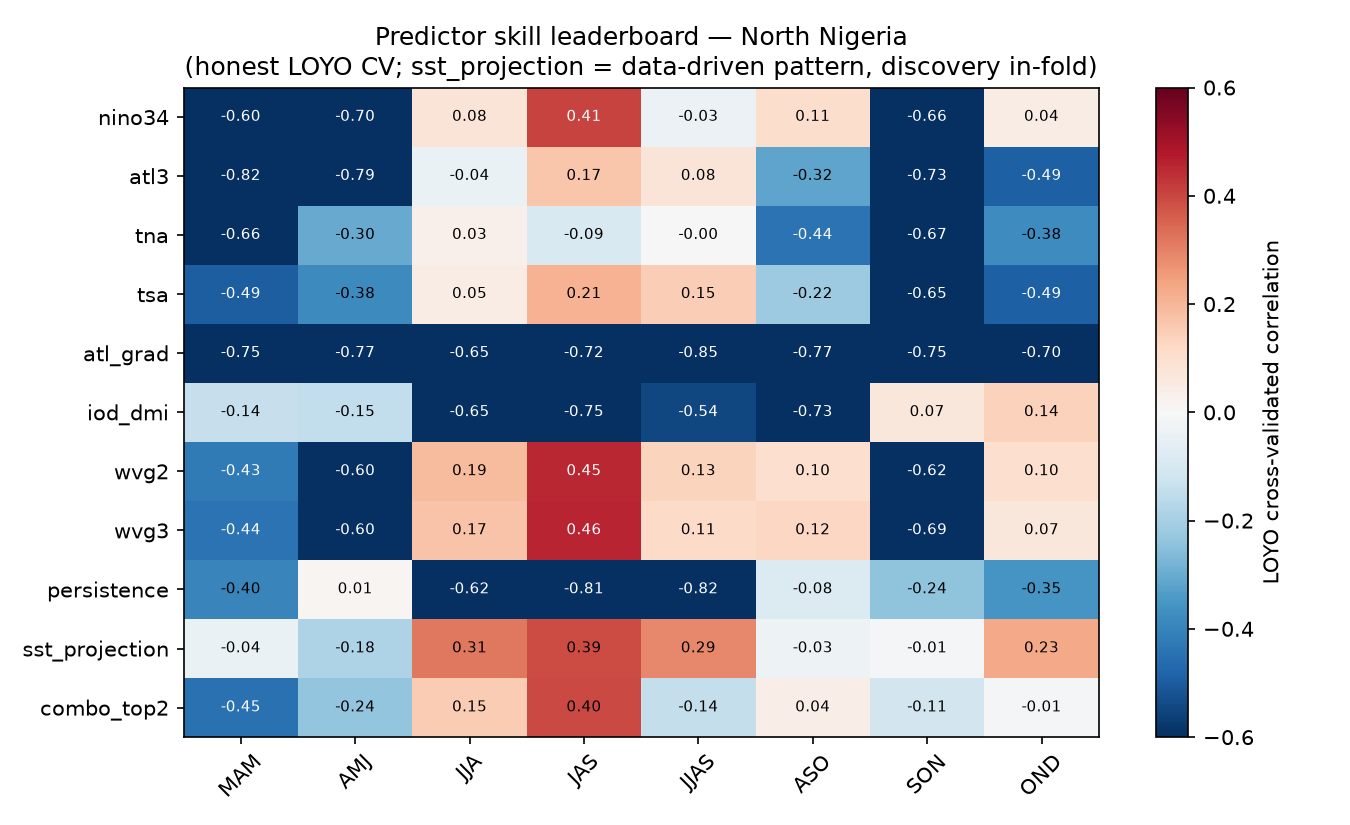

In [4]:
show('features_cv_skill_North.png', 'features_cv_skill_North_ethiopia.png')

## 3 · What ocean state sets up drought vs. flood?

Pre-season SST composites for the driest vs. wettest terciles recover the canonical teleconnections:

- **Ethiopia Kiremt** — the dry tercile is *dominated by* El Niño years (1997, 2002, 2009, 2015, 2023 are
  in it), though the 11-year tercile also includes some neutral/La-Niña years (e.g. 2011); the composite
  SST *pattern* is a clear El-Niño-like warm tongue. (The named years are illustrative, not the full tercile.)
- **Kenya / Greater-Horn OND** — the wet tercile is dominated by strong positive-IOD years (1997, 2019, 2023).

*Note on the drivers:* East African rainfall–SST links are strongest for the **OND short rains** (IOD/ENSO);
the **MAM long rains** are only weakly SST-linked — their controls are less SST-mediated (Walker/Congo
zonal winds, the MJO, western-Indian-Ocean/Arabian SST and the Somali jet), which is why they are hard to
predict at seasonal lead (Lyon & DeWitt 2012; Yang et al. 2014; Wainwright et al. 2019).

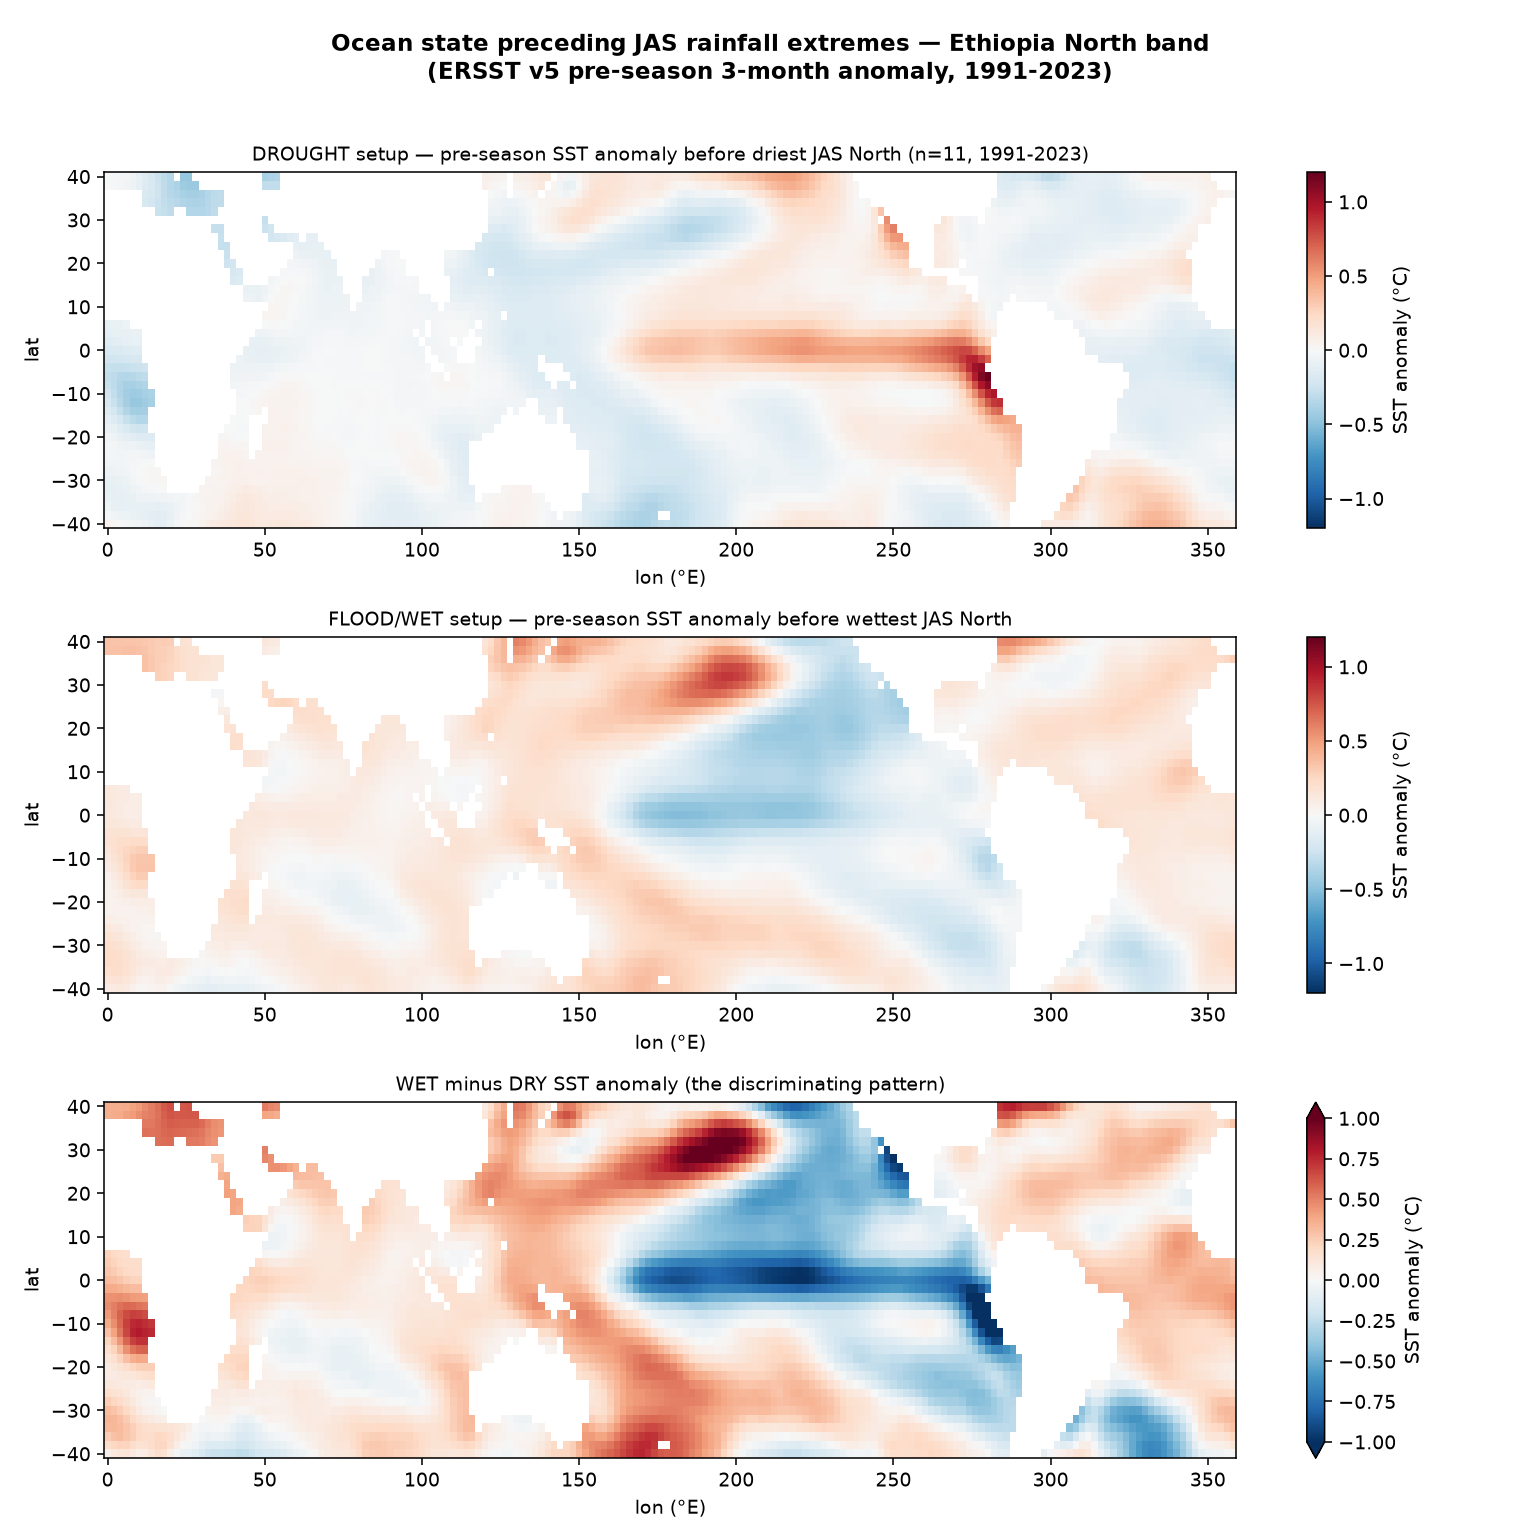

In [5]:
show('composite_JAS_North_ethiopia.png')

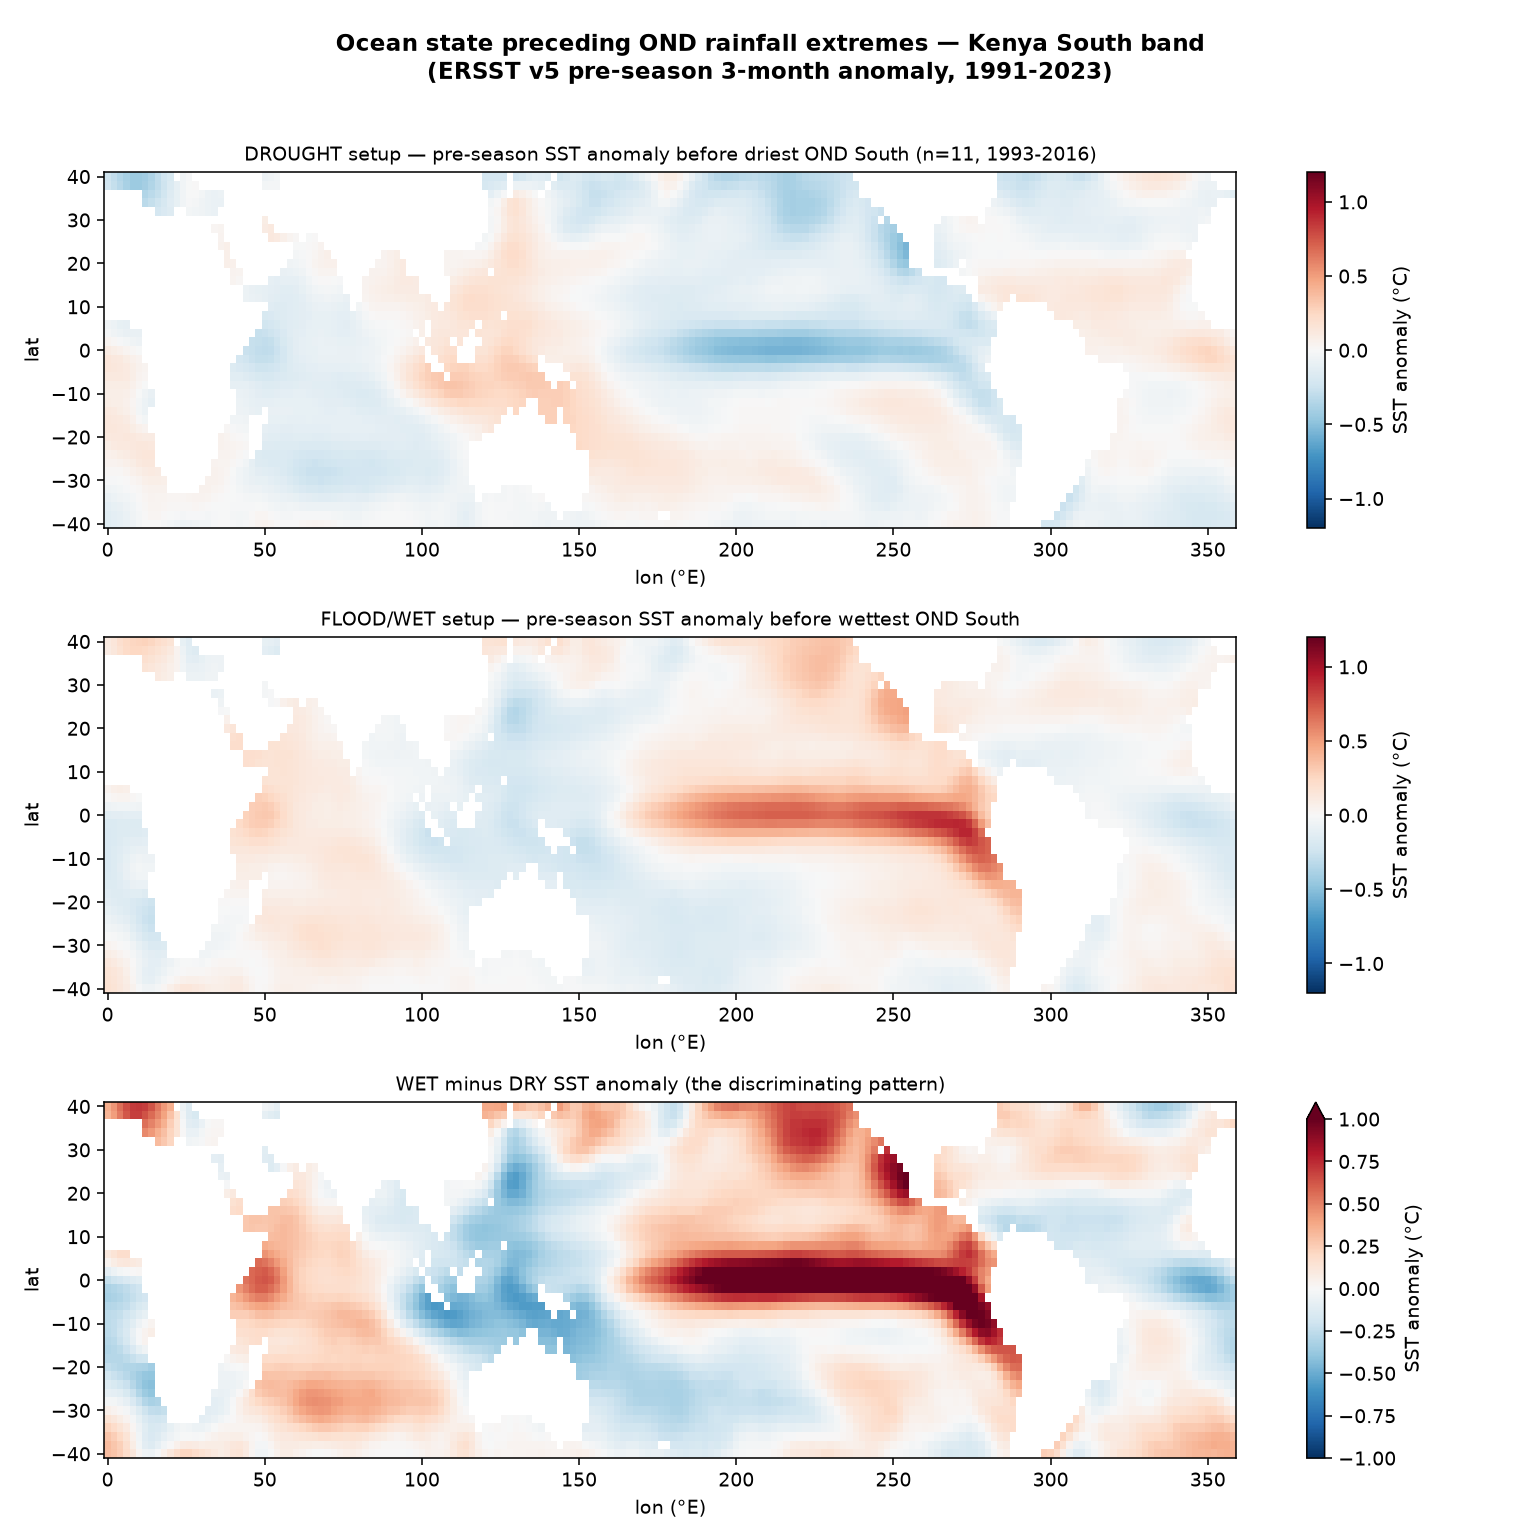

In [6]:
show('composite_OND_South_kenya.png')

## 4 · Real dynamical forecasts vs. the predictability ceiling

Everything above is *perfect prognosis* (observed SST → rainfall) — the **benchmark**. The dynamical step runs
a real NMME multi-model ensemble (CCA-MOS, LOYO) and compares against it. For **Nigeria, skill is marginal
for this ensemble and predictand** (GROC ≈ 0.46–0.50) even though the statistical benchmark is positive — the
rainfall-relevant Atlantic signal is hard for *this* system to exploit. That is consistent with known
West-African-monsoon forecast biases; it is **not** evidence that dynamical forecasting is impossible here
(better bias treatment, coupling, higher resolution, or regionalization could change it).

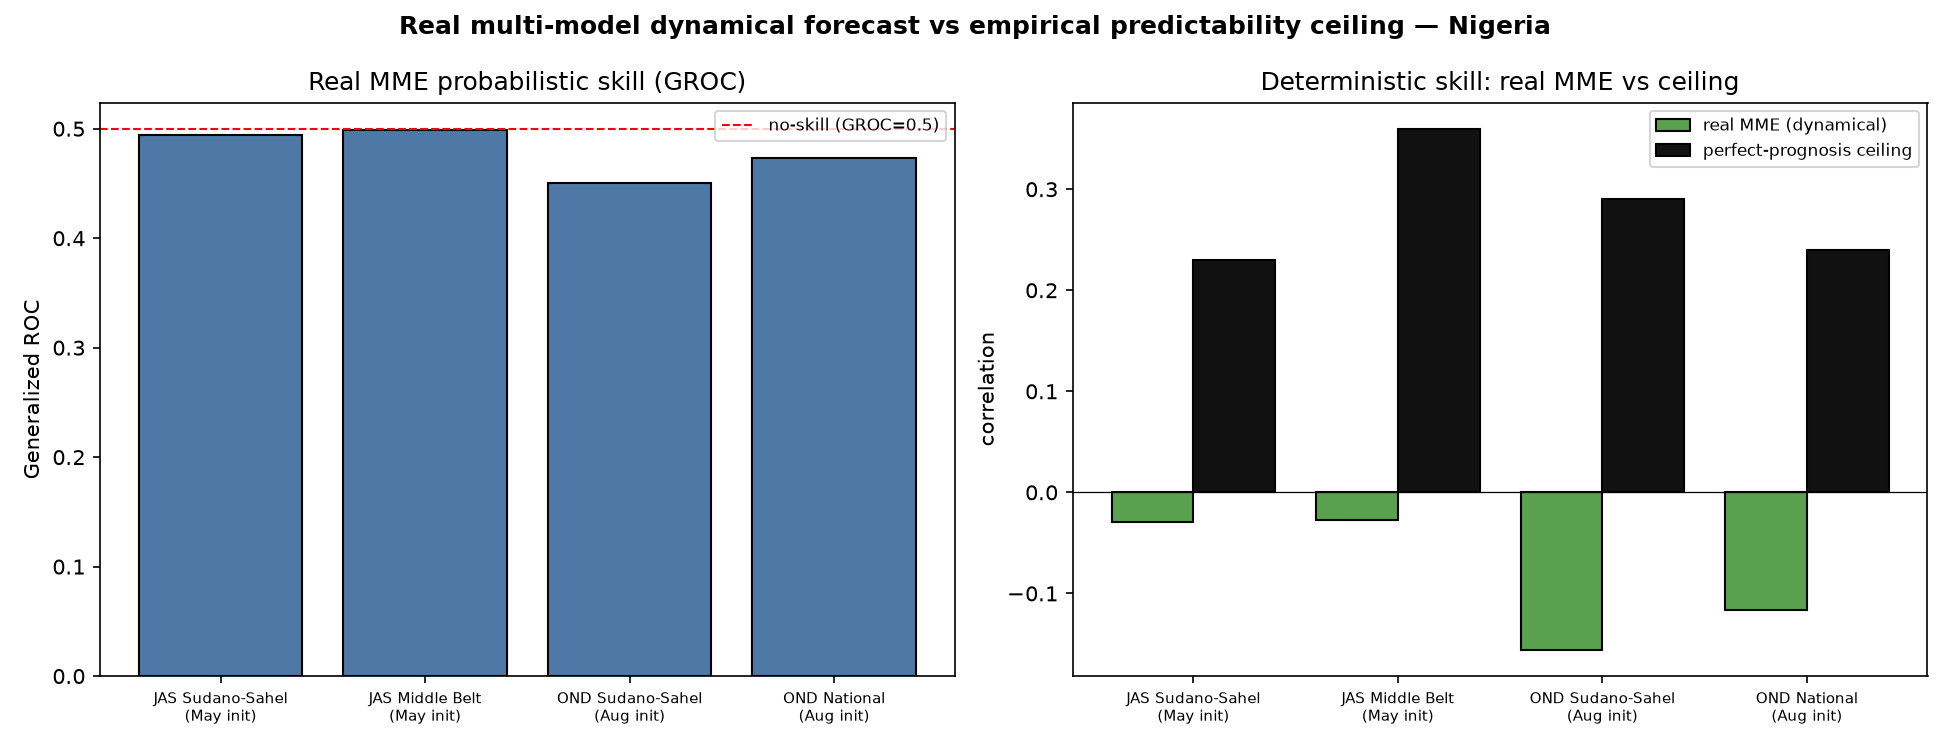

In [7]:
show('mme_vs_ceiling.png')

Searching the **SST predictor domain** and the **method** (CCA, BCSD, QM, delta, rank-analog …) does *not*
lift Nigerian skill in any robust way — and this is a place the earlier draft over-claimed:

- The GROC spread **across domains is only ~0.02–0.05**, inside the ~0.1 noise floor; the "best domain" is
  not robust, and picking it is largely selecting a noise winner.
- Where skill *does* exist (East African OND), the SST-teleconnection CCA **barely beats the plain
  precip-MOS baseline** (e.g. Kenya OND 0.708 global-tropical vs. 0.680 precip-MOS) — most of that skill is
  already in the raw model precipitation, as expected for the IOD-driven short rains.
- The method "winners" have **negative RPSS (−0.25 to −0.31)** even where GROC > 0.5 — i.e. worse than
  climatology as *probabilistic* forecasts. GROC-only "lifts" are not usable skill (annotations show RPSS).

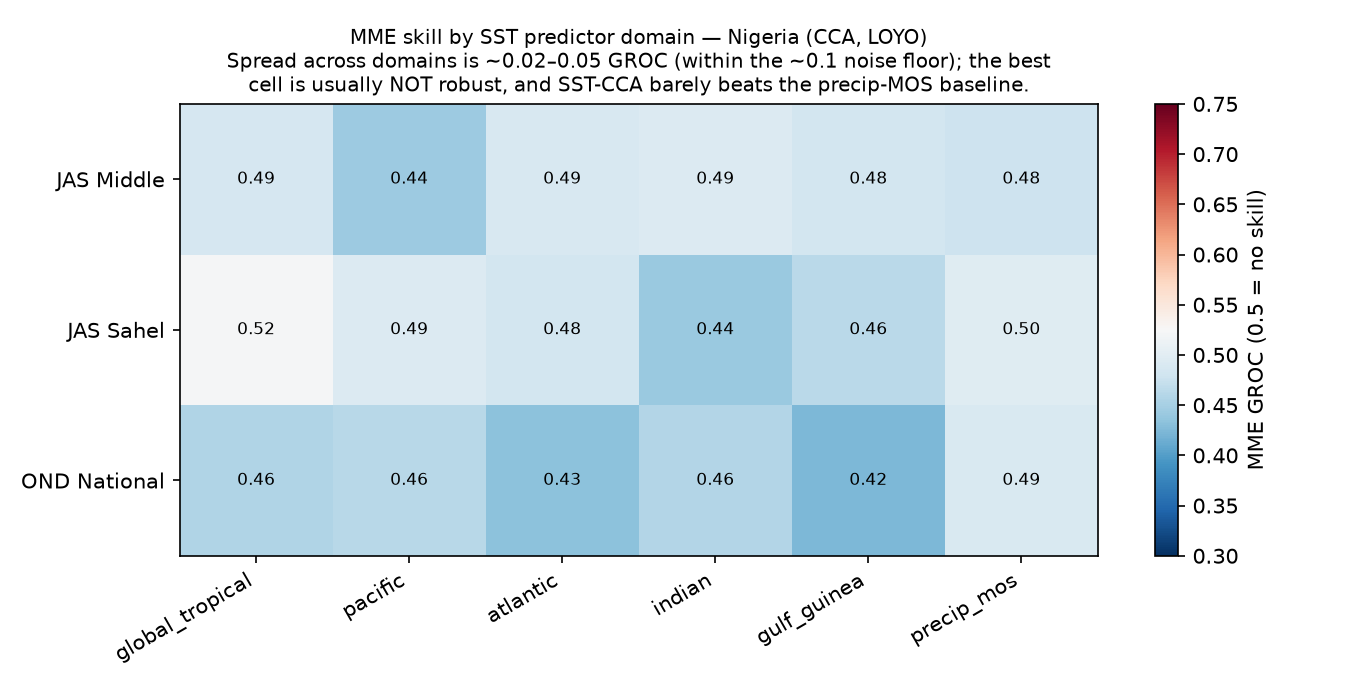

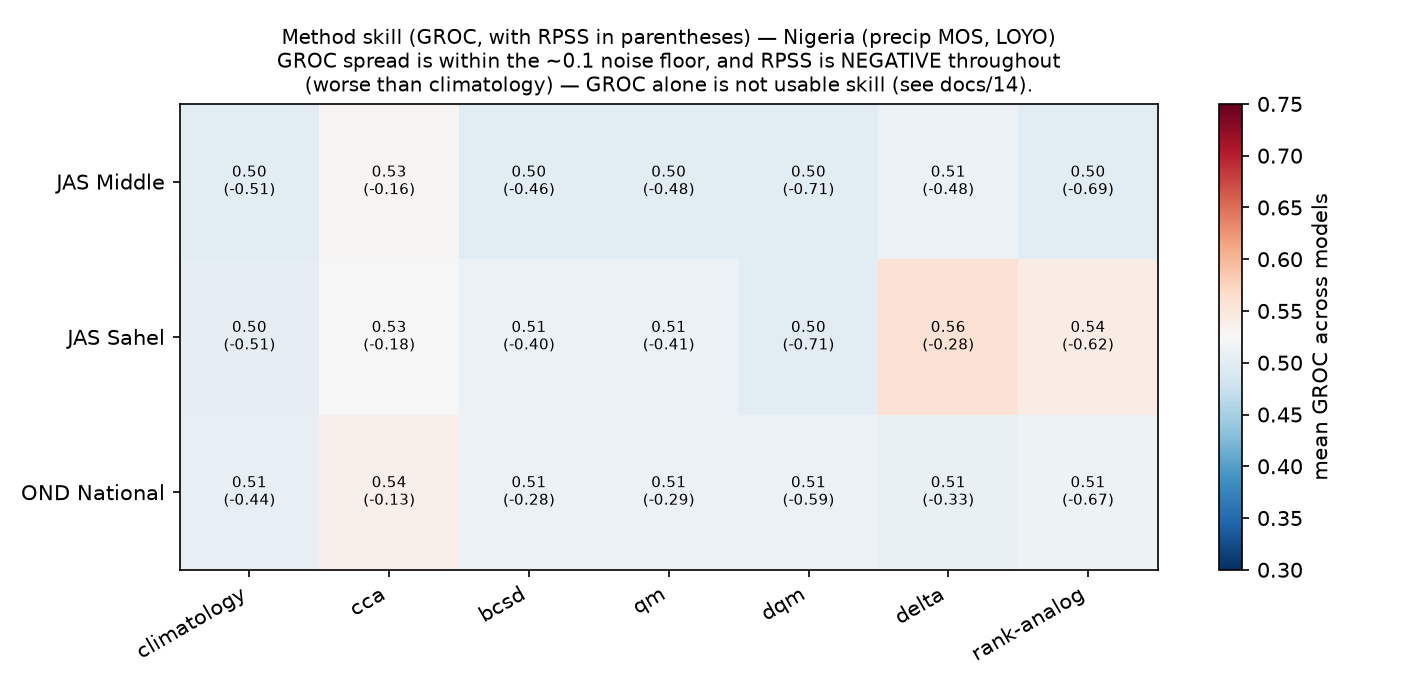

In [8]:
show('mme_domain_search.png', 'mme_method_search.png')

## 5 · The hybrid decomposition — *why* the dynamical forecast works, or doesn't

The hybrid feeds each model's **forecast SST** into the **observation-trained** SST→rainfall link, using the
*physically-appropriate, search-consistent* index per target (the Atlantic **gradient** for the Sahel — its
classical driver — *not* Niño3.4; the Atlantic Niño for the Guinea/Middle zone; the IOD for the short rains).
Two references are shown: the **lead predictability** (pre-season SST known in advance — the realistic bar)
and a **perfect-SST reference** (concurrent target-season SST → rain — an upper bound, and *partly diagnostic*
for the IOD since its western pole is coupled to the short rains within the season). The lead and hybrid
columns are what matter:

- **East Africa (skill realized):** OND short rains — **lead predictability ≈ 0.5**, hybrid **≈ 0.69–0.75**
  (Kenya/Ethiopia); Kiremt — lead ≈ 0.41, hybrid ≈ 0.58 — because the driver (IOD/ENSO) is comparatively
  well-forecast. The hybrid exceeds the *lead* value because the model's concurrent-season SST forecast
  carries more than pre-season SST alone.
- **Nigeria (skill limited):** with the Atlantic-appropriate indices, the hybrid is near zero — the Atlantic
  indices are forecast less well and/or their lead link is weaker for this predictand.
- **MAM long rains (low predictability):** lead ≈ 0, hybrid ≈ 0 — a genuinely low-skill season, not a
  configuration artifact.

(All n≈24; only the OND and Kiremt hybrid values clearly exceed the sampling-noise floor.)

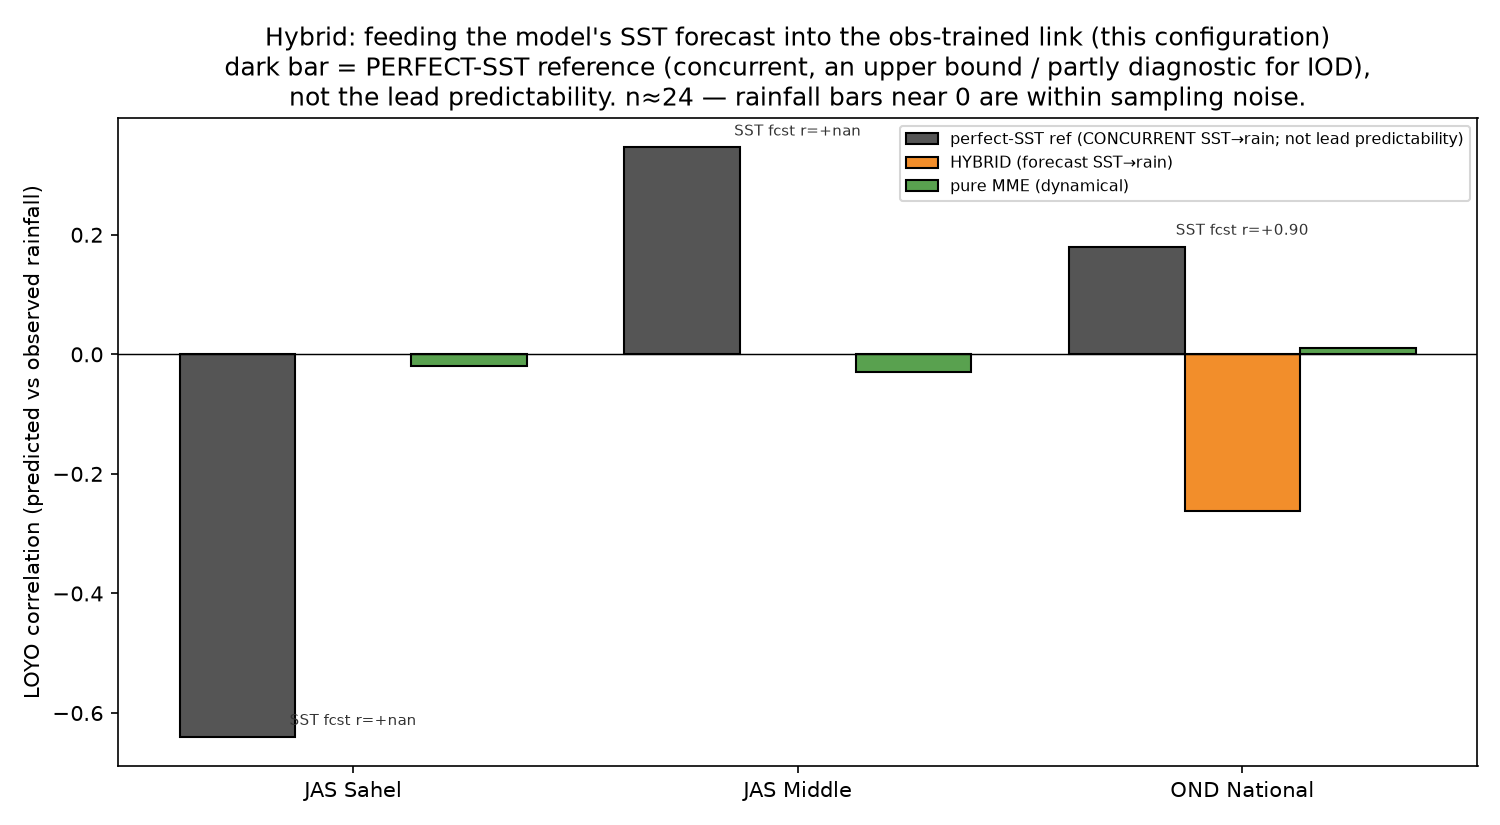

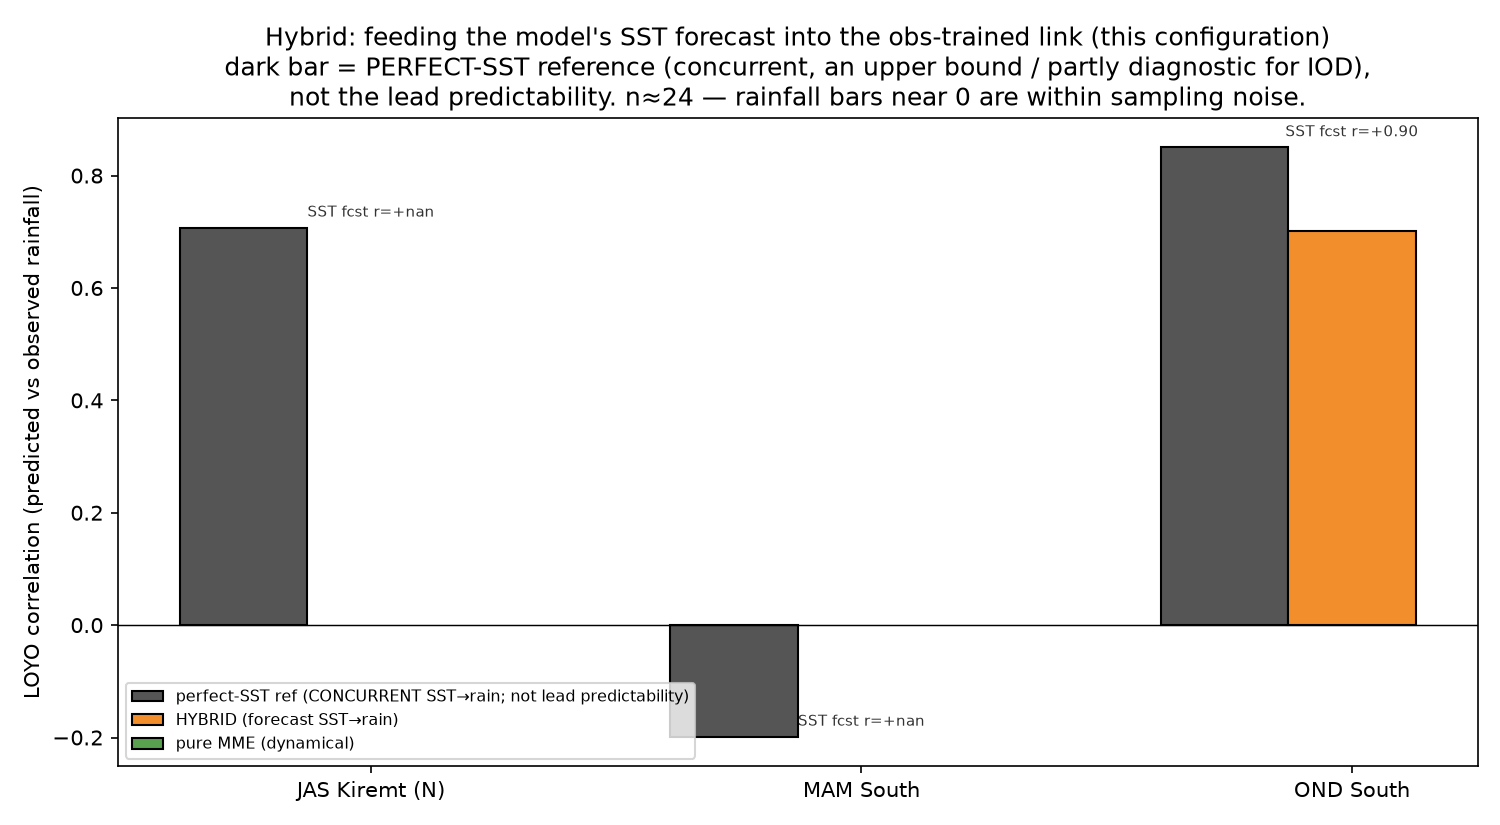

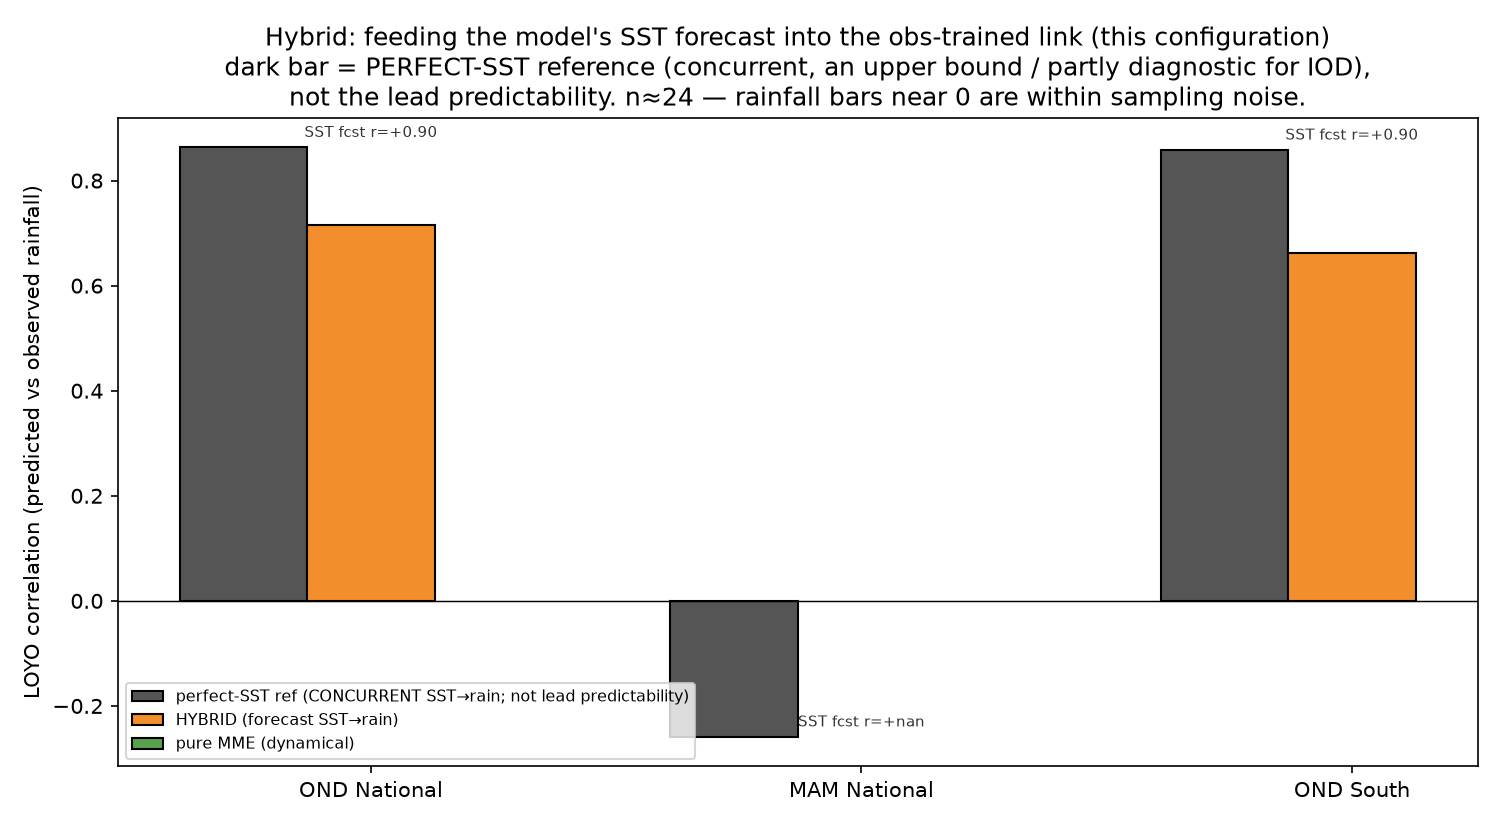

In [9]:
show('hybrid_forecast.png', 'hybrid_forecast_ethiopia.png', 'hybrid_forecast_kenya.png')

---
# Synthesis — a diagnostic ordering of where SST-based skill is realized

Run identically on three countries, the framework orders the seasons by a simple, physically-motivated
question used as a **diagnostic lens** (not a law): ***how strong is the statistical SST→rainfall link, and
how well can GCMs forecast the ocean index that carries it?*** The figure below places all 3 countries × 3
seasons in that plane — x = how well GCMs forecast the driver, y = strength of the statistical link (the
perfect-prognosis benchmark), colour = the hybrid skill actually achieved:

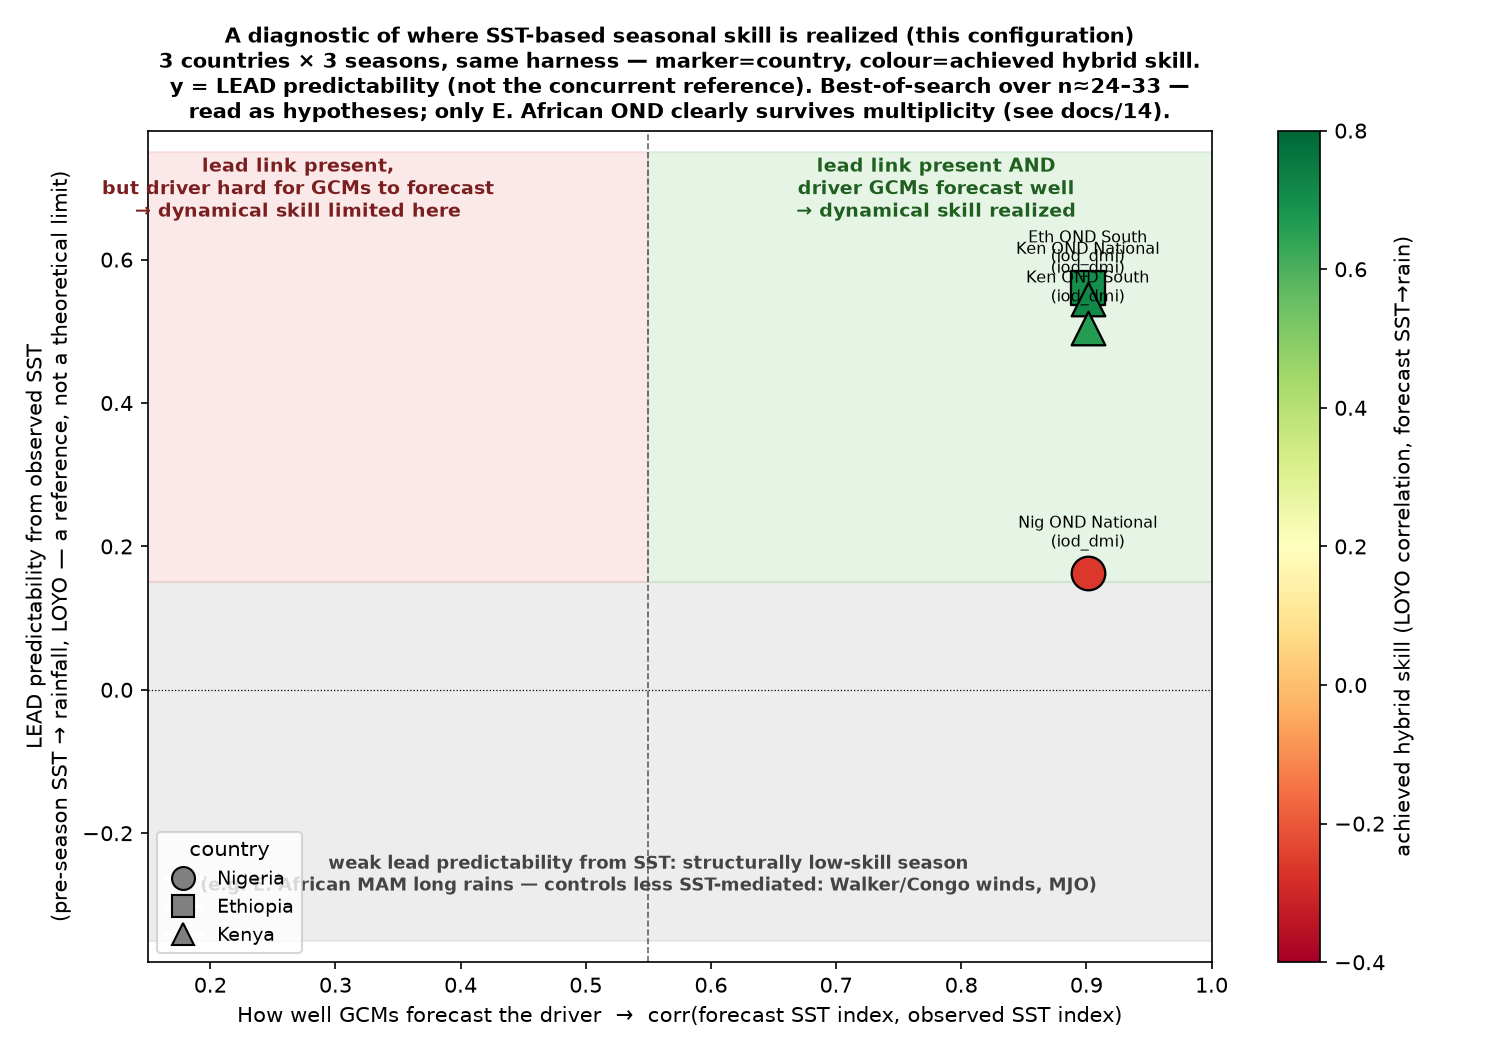

In [10]:
show('fig_taxonomy_scatter.png', width=920)

**The ordering that emerges** (empirical, configuration-specific — see limitations):

- **Skill realized** where a real *lead* link meets a well-forecast driver (the IOD/ENSO): **Kenya &
  Ethiopia OND short rains** (lead ≈ 0.5, hybrid ≈ 0.7) and **Ethiopian Kiremt** (top-right). The OND result
  is the strongest, most defensible signal in the study.
- **Skill limited despite a real lead link** where the driver is *hard for GCMs to forecast* — **Nigeria's
  Middle-Belt monsoon** (Atlantic Niño; lead ≈ 0.28 but forecastability ≈ 0.27, top-left). For *this*
  ensemble/predictand; not a statement that no system could do better.
- **Weak lead predictability from SST** (bottom): the **East African MAM long rains** (controls less
  SST-mediated — Walker/Congo zonal winds, the MJO, western-Indian-Ocean/Somali-jet — *not* driverless);
  and, for this predictand, the **Nigerian Sahel** (Atlantic-gradient lead link ≈ 0) and **Nigerian OND**
  (a forecastable IOD, but a weak Nigeria link ≈ 0.16).

The clearest single contrast — the **OND short rains**, the same season in all three countries — shows
higher real ensemble skill in East Africa, where the IOD link is strong and comparatively forecastable
(bars near the 0.5 line are within noise):

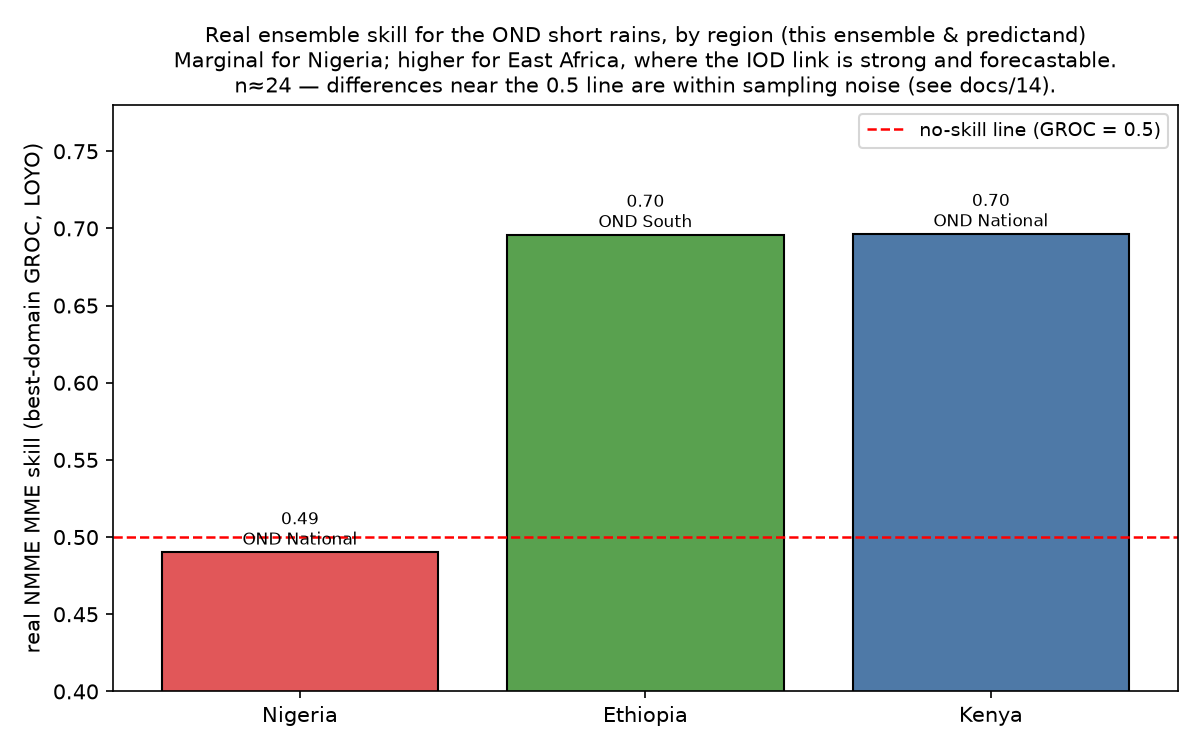

In [11]:
show('fig_ond_mme.png', width=720)

### Detrending check — do the headline correlations survive removing the shared warming trend?

A reviewer-style robustness check: recompute the LOYO skill of the headline predictors with **in-fold linear
detrending** of both series. Results below (`detrend_check.md`): the **East African OND/IOD skill survives
(even strengthens)**; Ethiopian Kiremt survives; the **weak MAM apparent signals collapse to ≈ 0** —
reinforcing that MAM is genuinely low-predictability. Nigeria's Atlantic textbook indices are largely
trend-robust here under proper in-fold detrending (the data-driven `sst_projection` pattern is the most
trend-exposed and should always be reported detrended).

In [12]:
import pandas as pd
from IPython.display import Markdown, display
p = 'outputs/tables/detrend_check.md'
try:
    display(Markdown(open(p).read()))
except FileNotFoundError:
    print('run src/detrend_check.py')

# Raw vs. in-fold-detrended LOYO skill (headline cells)

LOYO cross-validated correlation of a pre-season SST index with zone-mean seasonal rainfall, without and with in-fold linear detrending of both series. Survives detrending = interannual signal; collapses = rode the shared warming trend.

| Country | Season | Band | Index | r (raw) | r (detrended) |
|---|---|---|---|---|---|
| Nigeria | JAS | Sahel/North | nino34 | +0.09 | +0.13 |
| Nigeria | JAS | Sahel/North | wvg2 | +0.21 | +0.17 |
| Nigeria | JAS | Middle | atl3 | +0.28 | +0.25 |
| Nigeria | JAS | Middle | atl_grad | +0.36 | +0.44 |
| Nigeria | OND | National | iod_dmi | +0.16 | +0.24 |
| Nigeria | JAS | Sahel/North | sst_projection | +0.23 | +0.21 |
| Ethiopia | JAS | Kiremt/North | nino34 | +0.41 | +0.45 |
| Ethiopia | JAS | Kiremt/North | wvg3 | +0.46 | +0.48 |
| Ethiopia | OND | South | iod_dmi | +0.56 | +0.58 |
| Ethiopia | MAM | South | nino34 | -0.30 | -0.01  ⚠ |
| Ethiopia | JAS | Kiremt/North | sst_projection | +0.39 | +0.38 |
| Kenya | OND | National | iod_dmi | +0.54 | +0.57 |
| Kenya | OND | South | iod_dmi | +0.51 | +0.53 |
| Kenya | JAS | Central | wvg3 | +0.37 | +0.31 |
| Kenya | MAM | National | nino34 | -0.24 | +0.05  ⚠ |
| Kenya | OND | National | sst_projection | +0.45 | +0.52 |

⚠ = |r| drops by >0.10 under detrending (trend-inflated).



---
## 6 · Multiplicity control — which discovered signals survive the winner's curse?

The single biggest threat to a *search* over forecast design is that the best of hundreds of
cross-validated scores is upward-biased. Leave-one-year-out CV does **not** fix this. So we now put
every leaderboard cell through a **permutation test** (5000 label shuffles per (season × zone × index)
cell) and control the false-discovery rate across all cells per country with **Benjamini–Hochberg**.
Two details matter: the permutation null for a leave-one-out correlation is **biased negative** (a
zero-signal predictor scores ≈ −0.36, not 0), so the test is one-sided against that null; and dry-season
cells with near-zero rainfall are excluded (they manufacture spurious |r|). What survives FDR is
defensible as more than best-of-search noise.

# Multiplicity control — permutation FDR over the feature leaderboard

Permutation test (5000 shuffles) per (season, band, textbook index) cell, then Benjamini–Hochberg FDR across all cells per country. Only cells that survive are defensible as more than best-of-search noise.

| Country | cells | survive q<0.05 | survive q<0.10 | strongest survivors (q<0.10) |
|---|---|---|---|---|
| Nigeria | 144 | 0 | 0 | — |
| Ethiopia | 208 | 10 | 12 | OND South·iod_dmi (r=+0.56, q=0.017); OND South·nino34 (r=+0.55, q=0.017); OND South·wvg2 (r=+0.49, q=0.024); OND South·wvg3 (r=+0.47, q=0.024); SON South·nino34 (r=+0.46, q=0.017) |
| Kenya | 160 | 27 | 35 | OND North·iod_dmi (r=+0.57, q=0.006); OND National·iod_dmi (r=+0.54, q=0.006); OND Central·iod_dmi (r=+0.52, q=0.006); OND South·iod_dmi (r=+0.51, q=0.006); OND National·nino34 (r=+0.50, q=0.009) |


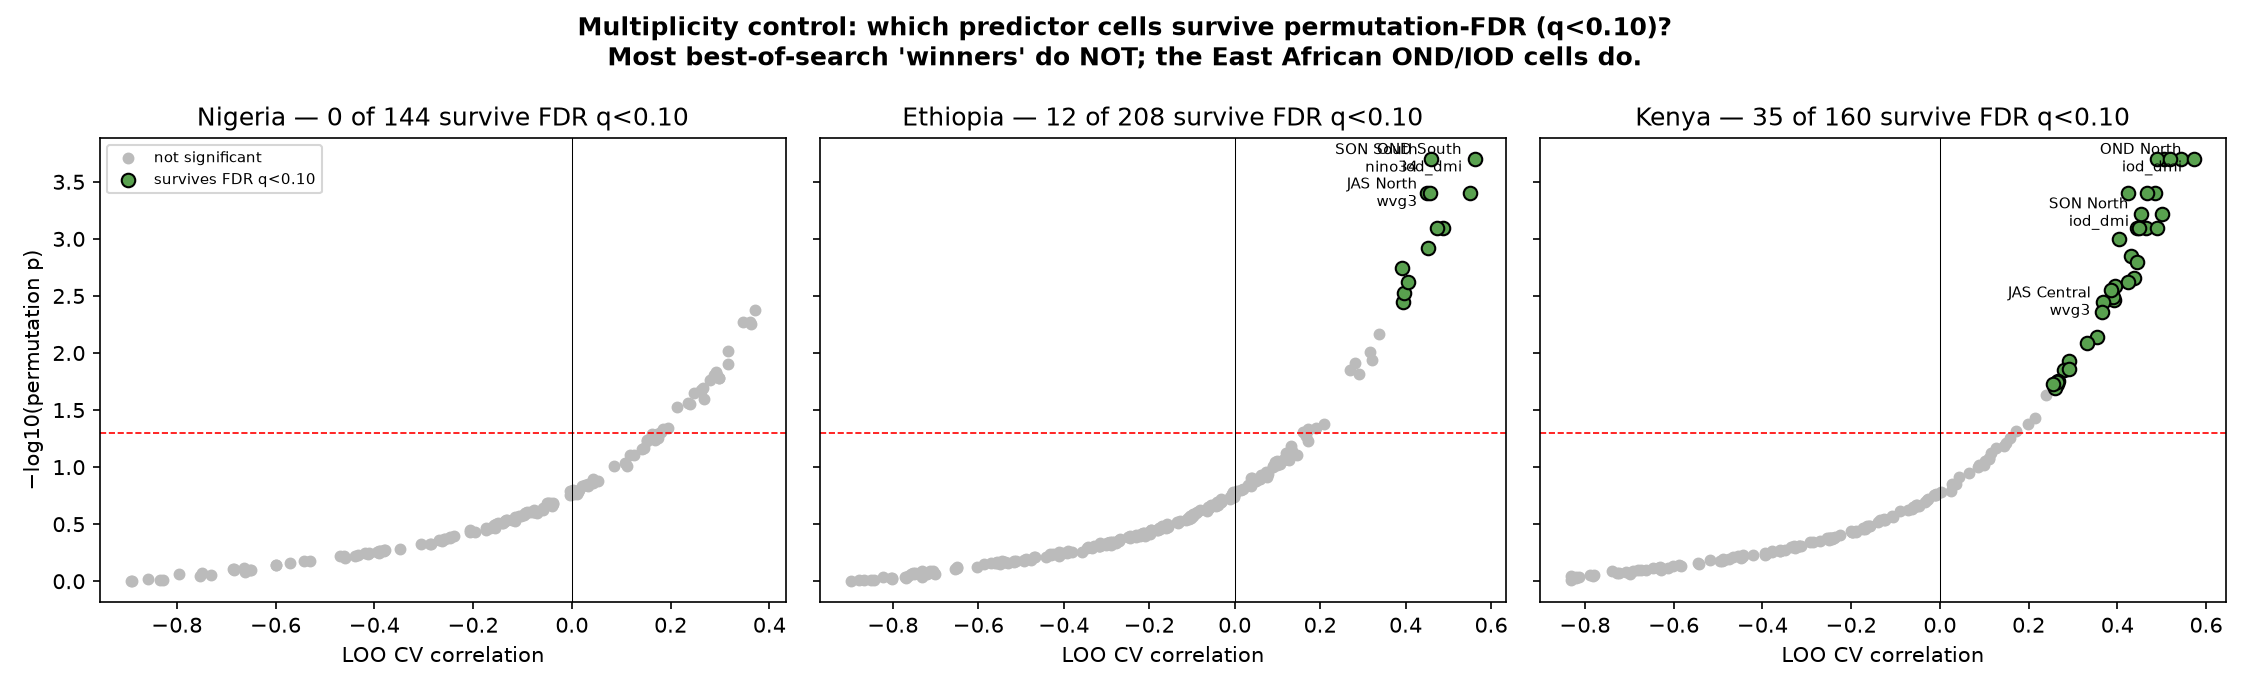

In [13]:
from IPython.display import Markdown, display
display(Markdown(open('outputs/tables/multiplicity_fdr.md').read()))
show('multiplicity_fdr.png', width=900)

The result is decisive and, encouragingly, *strengthens* the honest core of the study rather than
weakening it. **Nigeria / West Africa: nothing survives** — every West-African "winner" (|r| ≈ 0.2–0.35)
is within the best-of-search noise for this configuration, exactly as the measured reading warned.
**East African OND short rains: a large, coherent family survives** at q < 0.05 (Kenya 27 cells,
Ethiopia 10), all of them the physically expected IOD/ENSO predictors of the short rains. This is not one
lucky cell; it is a dense, mutually-consistent block — the signature of a real signal, not a fluke.

### Out-of-sample confirmation — a held-out block the search never saw

FDR guards against multiplicity *within* the search window. The complementary test is temporal: fit the
headline predictor on **1991–2009** and score it on a **2010–2023 block held out entirely** from fitting.

In [14]:
display(Markdown(open('outputs/tables/heldout_block.md').read()))

# Held-out block test — train 1991–2009, test 2010–2023 (out-of-sample)

| Country | Season | Zone | Index | in-sample LOO r | **out-of-sample r (2010–2023)** |
|---|---|---|---|---|---|
| Nigeria | JAS | Middle | atl3 | +0.28 | **+0.29** |
| Ethiopia | OND | South | iod_dmi | +0.56 | **+0.75** |
| Ethiopia | JAS | Kiremt | wvg3 | +0.46 | **+0.58** |
| Kenya | OND | National | iod_dmi | +0.54 | **+0.75** |
| Kenya | MAM | National | nino34 | -0.24 | **+0.07** |


The East African OND relationships don't just hold out of sample — they come in **stronger** (Kenya
IOD 0.54 → 0.75; Ethiopia south 0.56 → 0.75; Kiremt 0.46 → 0.58). Nigeria's Atlantic (atl3) signal is
**stable but modest** (0.28 → 0.29): real, small, and honestly bounded. Kenya's MAM long rains
**collapse** (−0.24 → +0.07), reinforcing that MAM is genuinely low-predictability, not merely
under-fit. Between FDR and the held-out block, "read these as hypotheses" becomes, for East African OND,
"read these as a validated result."

## 7 · Predictand definition — do the discovered zones beat latitude bands?

A reviewer flagged that the forecasts use **latitude-band** zonal means, while the seasons were
discovered as **k-means zones** — and bands can blend anti-phased regimes (Ethiopia's western Kiremt
highlands vs. eastern lowlands being the worst case). We wired the saved zones in as predictands and
compared, for each country's key target, the LOYO CV skill of the best discovered **zone** vs. the
**band**.

# Discovered zones vs. latitude bands as predictands (LOYO CV skill)

For each country's key (season, driver) target: best discovered-ZONE skill vs. the latitude-BAND skill the study used. Where the zone beats the band, the band was diluting the signal by blending regimes.

| Country | Target | Index | best zone (lat) | **zone LOO r** | band LOO r |
|---|---|---|---|---|---|
| Nigeria | JAS monsoon | atl3 | zone 1 (~6.6°N) | **+0.36** | +0.28 |
| Nigeria | OND short rains | iod_dmi | zone 2 (~9.0°N) | **+0.13** | +0.16 |
| Ethiopia | Kiremt (JAS) | wvg3 | zone 2 (~10.8°N) | **+0.42** | +0.46 |
| Ethiopia | OND short rains | iod_dmi | zone 0 (~6.0°N) | **+0.56** | +0.56 |
| Kenya | OND short rains | iod_dmi | zone 3 (~2.1°N) | **+0.57** | +0.54 |
| Kenya | MAM long rains | nino34 | zone 0 (~-2.4°N) | **-0.93** | -0.24 |


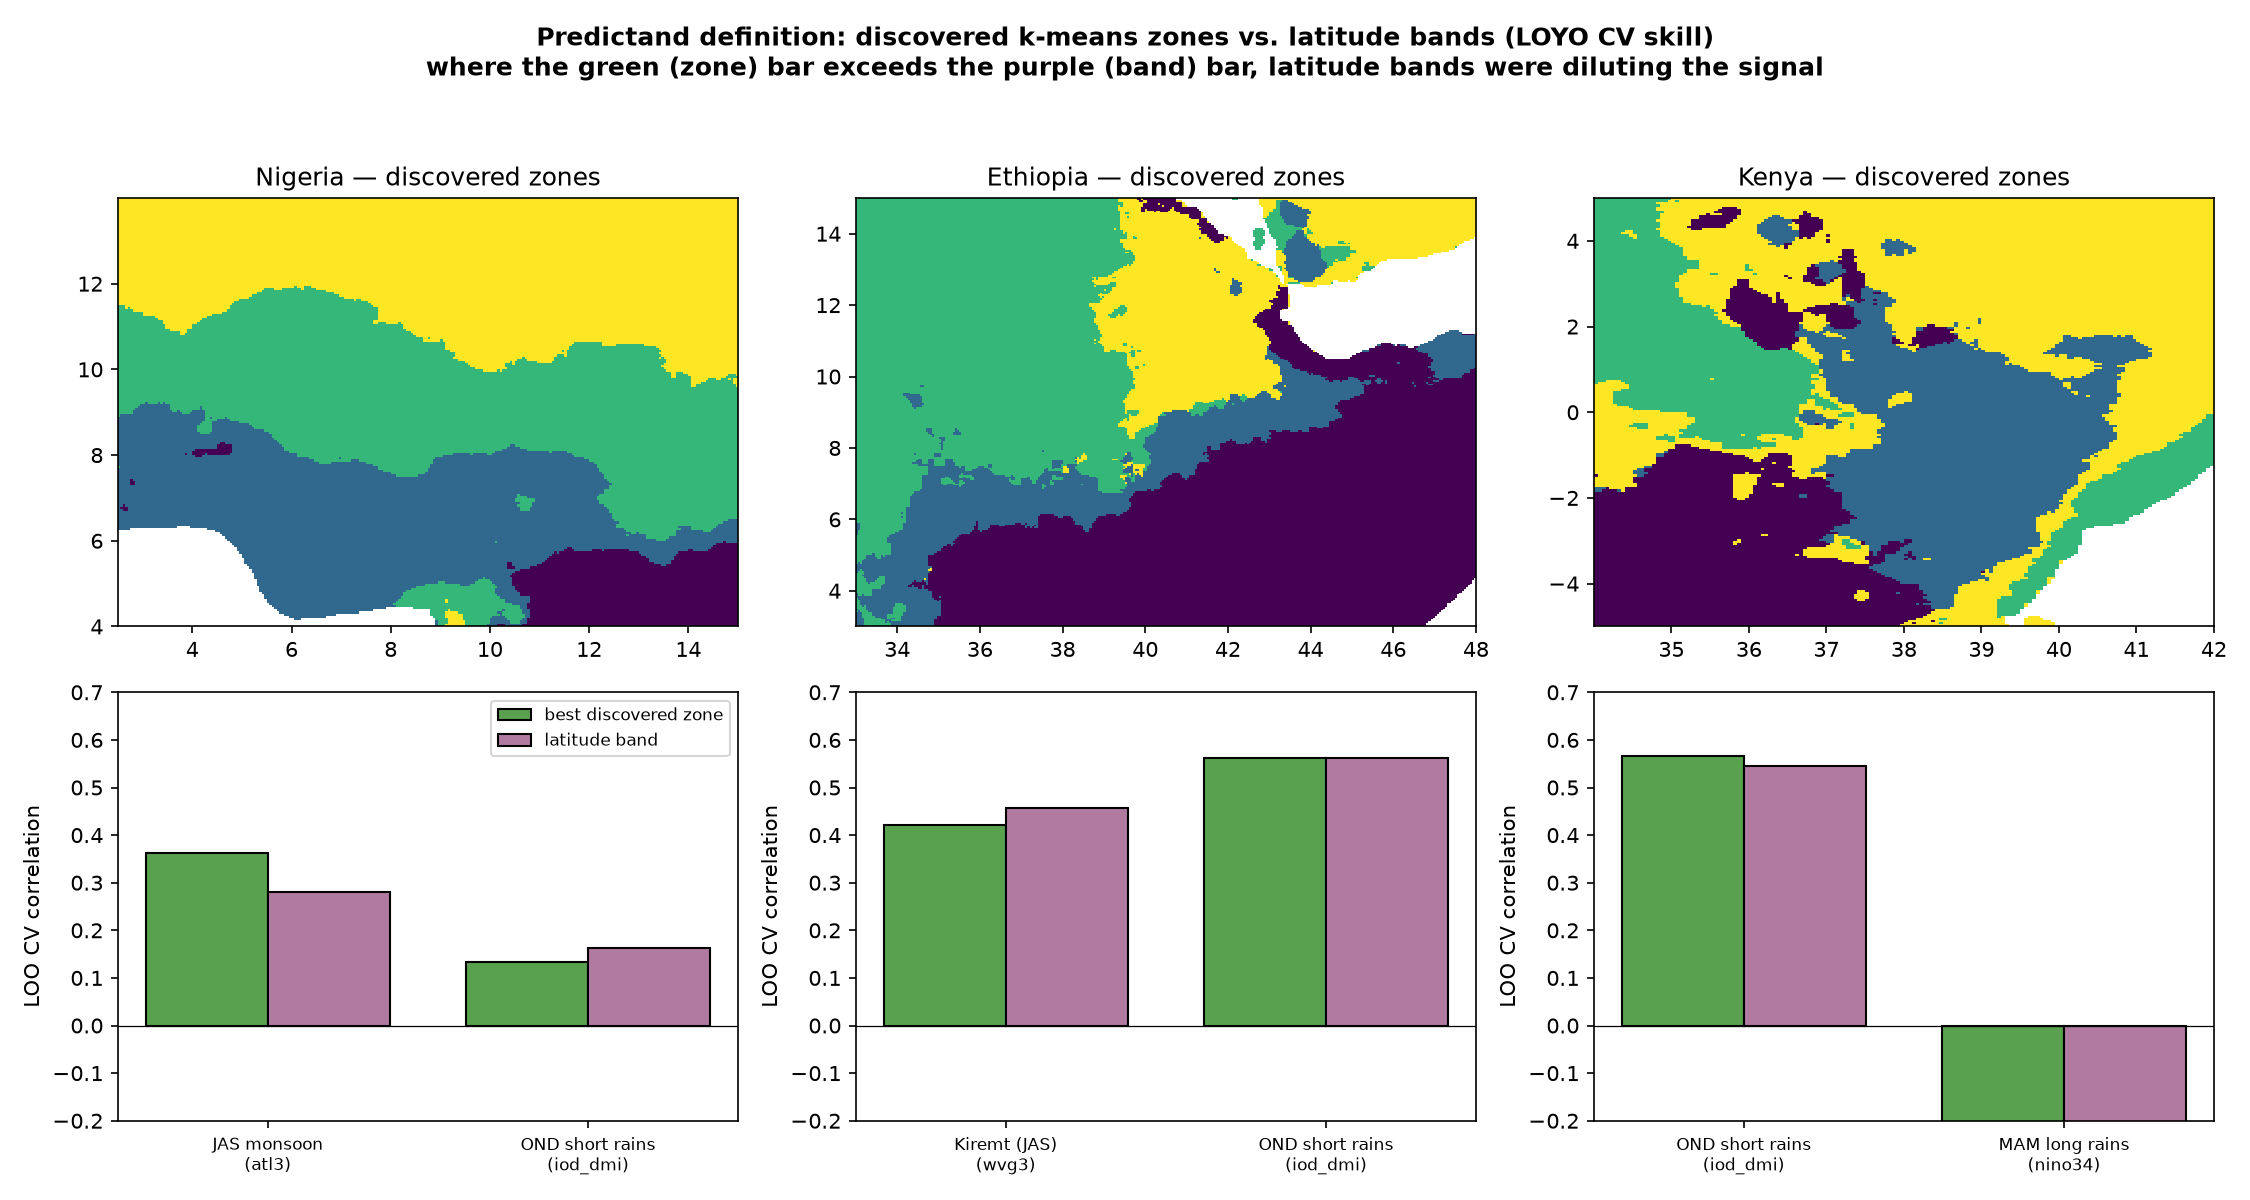

In [15]:
display(Markdown(open('outputs/tables/zones_vs_bands.md').read()))
show('zones_vs_bands.png', width=980)

The honest verdict is *modest*: zones give a cleaner signal where a regime boundary cuts across a band
(**Nigeria JAS monsoon 0.28 → 0.36**; Kenya OND 0.54 → 0.57) and are otherwise close to the bands — which
means the band results were a reasonable proxy, not a systematic distortion, for these mostly-latitudinal
targets. (MAM stays no-skill either way; its zone value is an unstable LOO artifact.) The reviewer's
concern is real in principle and small in practice for this study's specific season/zone choices.

## 8 · Skill vs. accuracy, as a function of forecast lead time

Two things are often conflated and are **not** the same. **Skill** asks *is the forecast better than
climatology?* (RPSS, generalized-ROC, correlation — 0.5 GROC / 0 RPSS = no better than climatology).
**Accuracy** asks *how often is it simply right?* (the tercile hit rate — fraction of years the
most-likely predicted tercile matched the observed one). A forecast can be fairly accurate yet have no
skill, because for a skewed predictand climatology is also accurate. We run the real NMME MME (CCA-MOS,
LOYO) from a sequence of initialisations to trace both against lead time, per region.

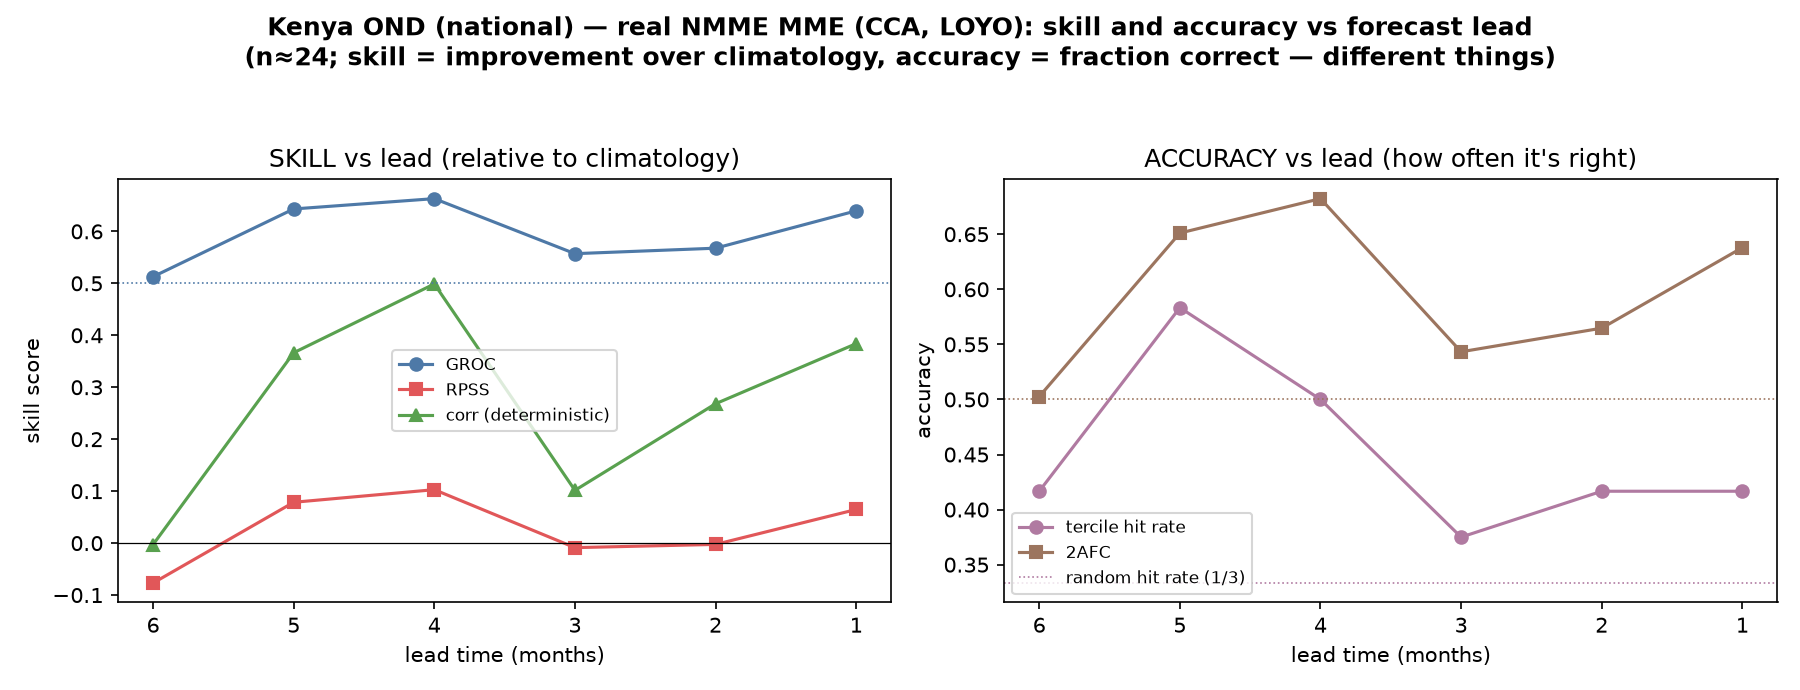

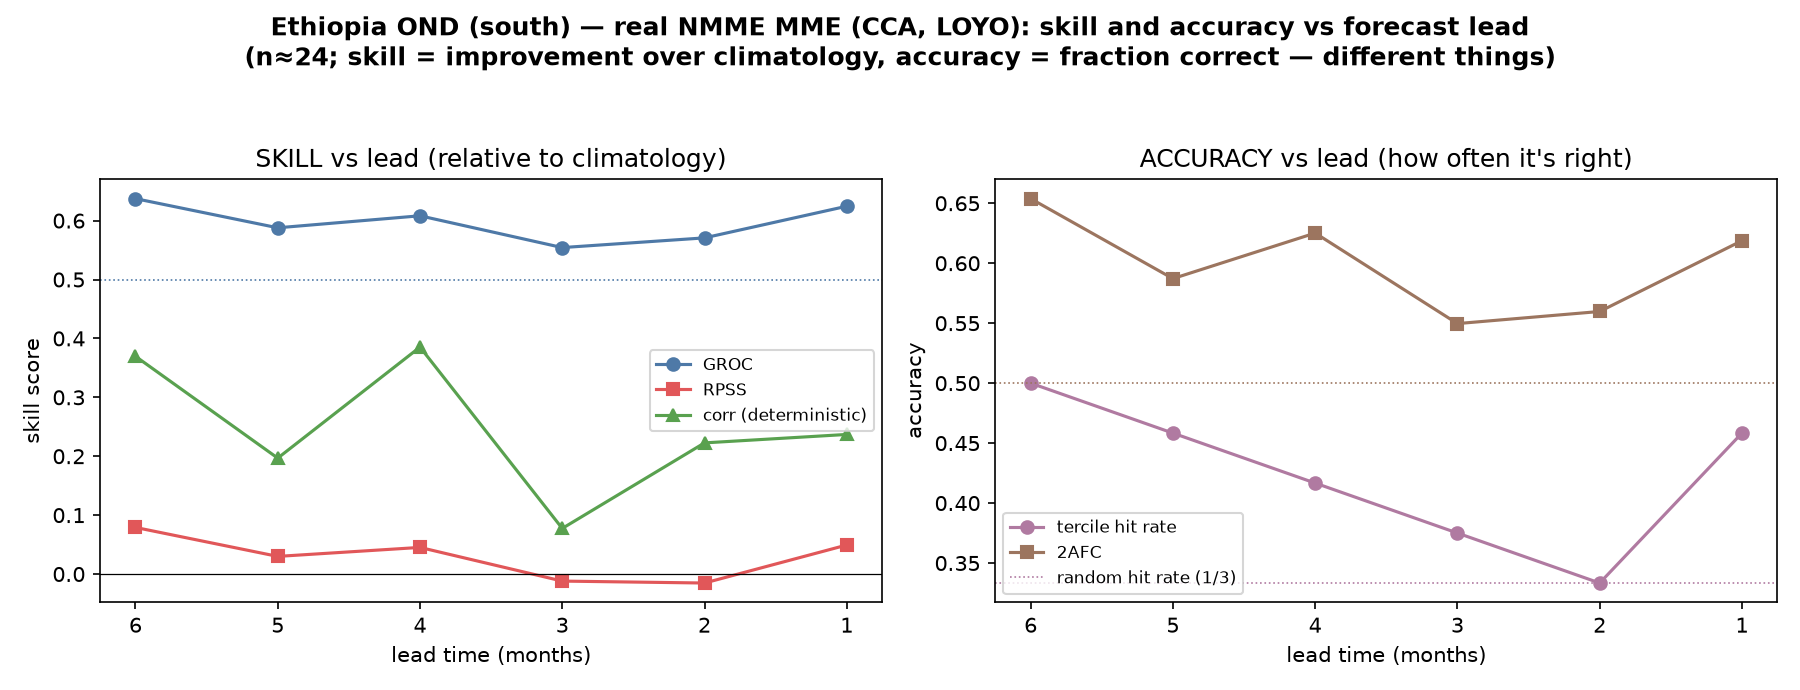

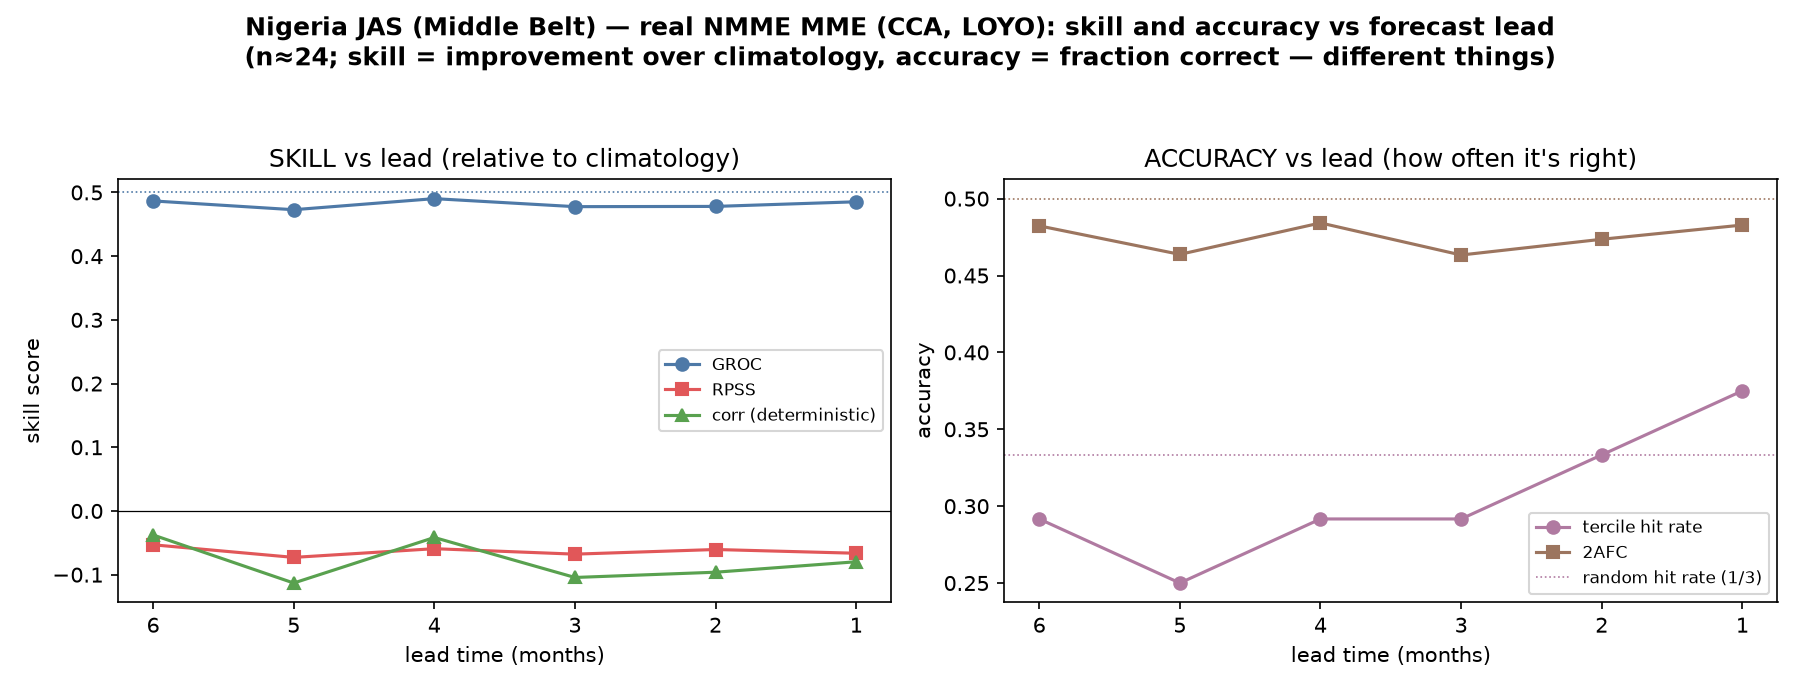

In [16]:
for f in ['lead_skill_kenya.png', 'lead_skill_ethiopia.png', 'lead_skill_nigeria.png']:
    try: show(f, width=900)
    except Exception: print('run src/lead_skill.py to generate', f)

**What the curves actually show.** GROC by lead time (months):

| lead | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| Kenya OND (national) | 0.640 | 0.568 | 0.557 | 0.663 | 0.643 | 0.513 |
| Ethiopia OND (south) | 0.624 | 0.571 | 0.554 | 0.608 | 0.588 | 0.637 |
| Nigeria JAS (Middle Belt) | 0.485 | 0.478 | 0.478 | 0.490 | 0.473 | 0.487 |

Two results, one of them not what a textbook would predict.

**1 · East African OND skill does not decay with lead.** There is no systematic decline from 1 to 6 months;
GROC simply scatters in a band (~0.51–0.66) with no trend. That is physically coherent rather than
anomalous: the short rains are driven by the IOD/ENSO state, which is itself slowly varying and predictable
seasons ahead, so a forecast issued in June is not much worse informed about OND than one issued in
September. It also means **the useful planning horizon is set by the driver's predictability, not by the
lead time of the rainfall forecast** — the practical takeaway for early action.

**2 · Nigeria is a clean null at every lead** (0.473–0.490, *below* the 0.5 no-skill line, with negative RPSS
throughout). This corroborates the FDR result of Section 6 — where no West-African cell survived — by a
completely independent route, which is stronger evidence than either test alone.

**How much to trust the wiggles:** not much, individually. Kenya and Ethiopia track each other closely at
short leads (0.640/0.624, 0.568/0.571, 0.557/0.554 — within ~0.02), which is reassuring for two
independently-fetched regions sharing a driver. But they *disagree* at lead 6 (0.513 vs 0.637), precisely
where a single fold has the least support at n≈24. Both regions also show an uptick at lead 4, which may be
a genuine initialisation effect or may be shared sampling noise — this configuration cannot distinguish the
two. Read the **band**, not the individual points.

**Skill vs. accuracy.** The two panels are not redundant. Nigeria's tercile hit rate wanders around 0.25–0.38
while its GROC sits below 0.5: a forecast can be "right" at roughly the base rate without adding any
information. Kenya's hit rate actually *rises* with lead (0.42 → 0.58) even as GROC stays flat — hit rate is
sensitive to how the predictand's terciles happen to fall, which is exactly why it must not be read as skill.
Plotting both on the same lead axis is what makes that distinction legible.

## 9 · The downscaling resolution/skill frontier — how fine can we go?

The final search axis is spatial resolution. A coarse (~1°) dynamical forecast can be interpolated to any
grid, but the **verified** skill only follows to the resolution where a predictable fine-scale signal
actually exists. We downscale the East African OND forecast to progressively finer target grids —
1.0° → 0.05° (≈ 110 km → 5.5 km near the equator) — with several DeepScale methods, and re-verify LOYO
GROC against CHIRPS at each resolution. The frontier is where skill falls toward 0.5; the best method is
the one whose curve stays highest longest.

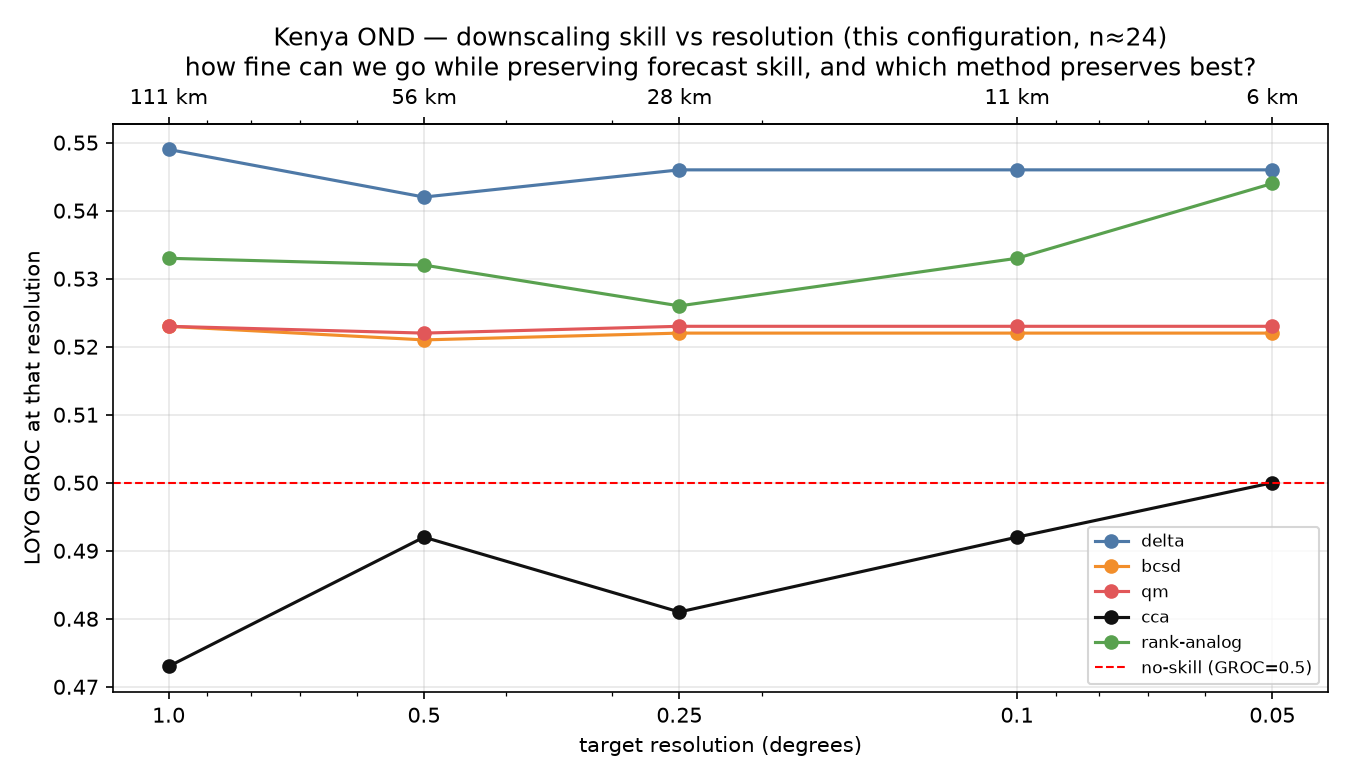

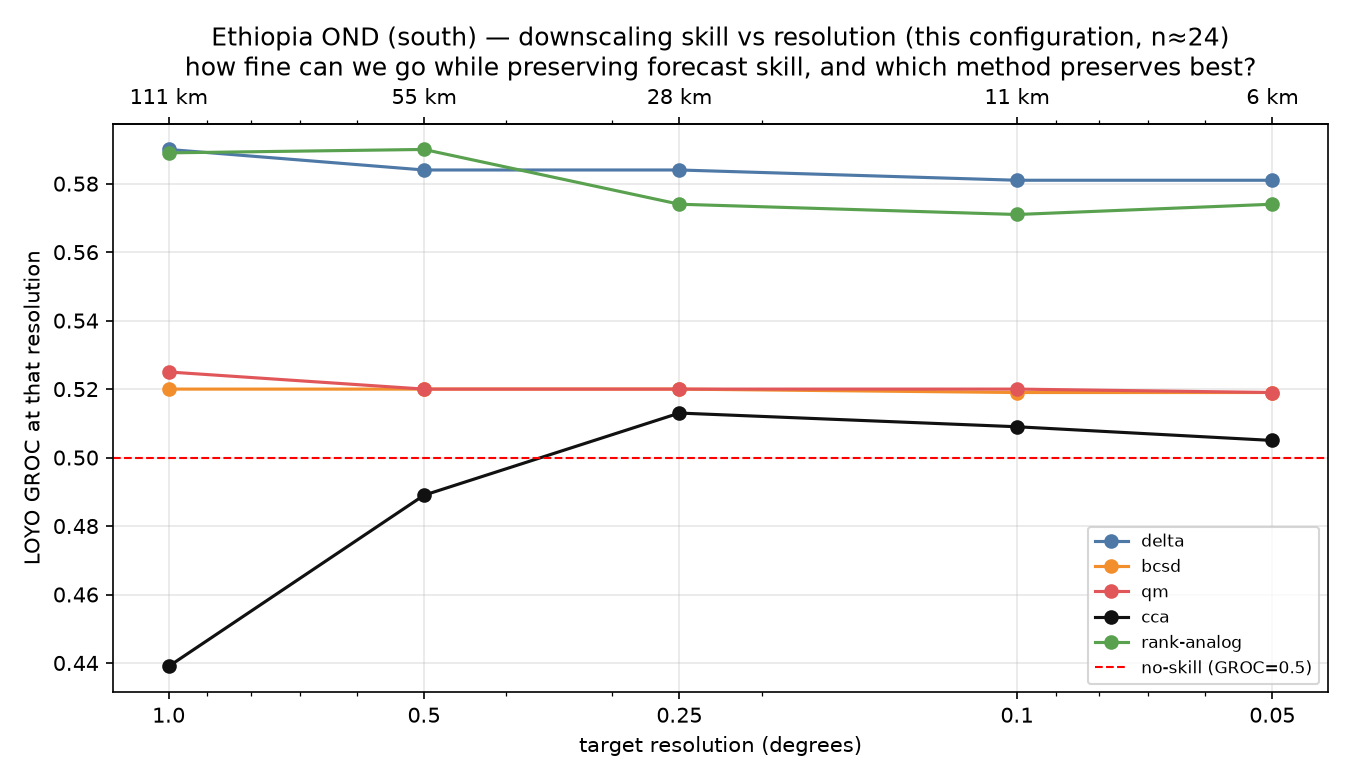

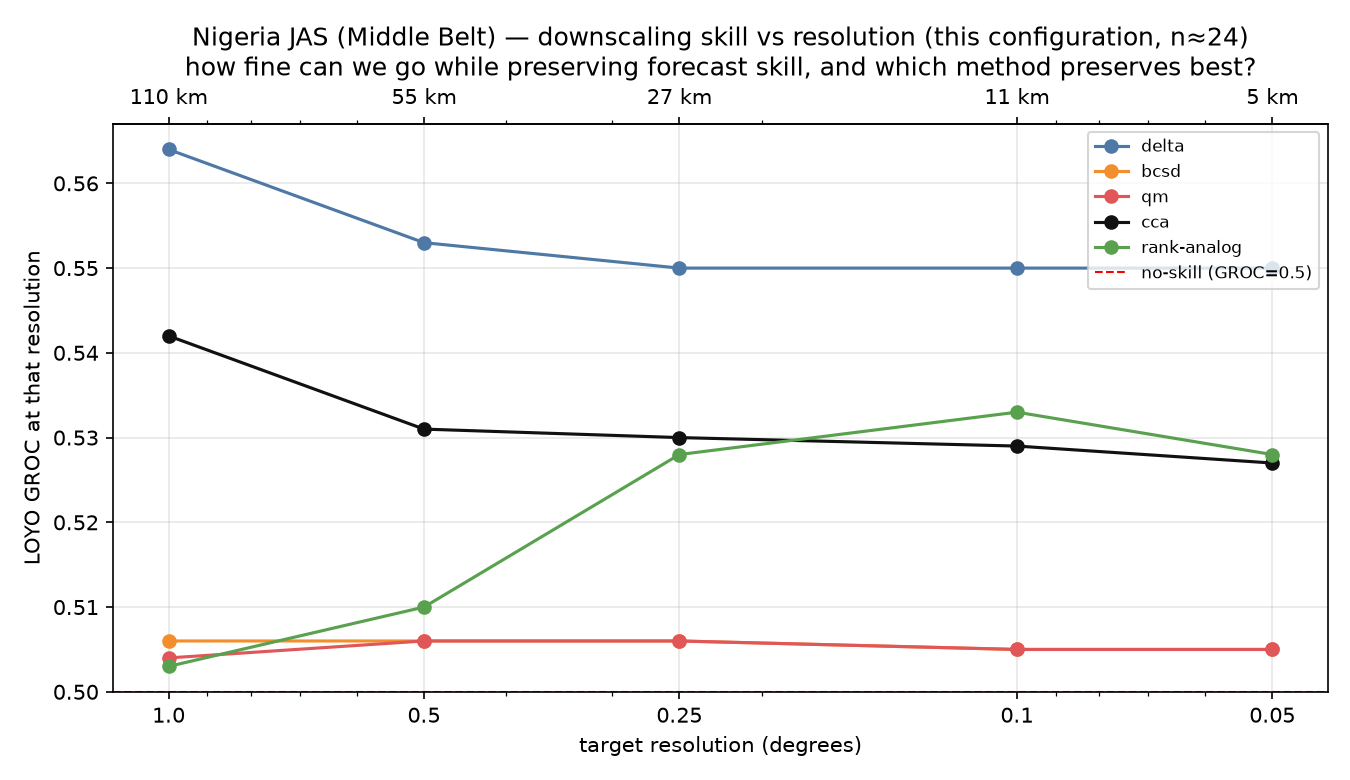

region | method | res_deg | res_km | groc
Kenya OND | delta | 1.0 | 111.3 | 0.549
Kenya OND | bcsd | 1.0 | 111.3 | 0.523
Kenya OND | qm | 1.0 | 111.3 | 0.523
Kenya OND | cca | 1.0 | 111.3 | 0.473
Kenya OND | rank-analog | 1.0 | 111.3 | 0.533
Kenya OND | delta | 0.5 | 55.7 | 0.542
Kenya OND | bcsd | 0.5 | 55.7 | 0.521
Kenya OND | qm | 0.5 | 55.7 | 0.522
Kenya OND | cca | 0.5 | 55.7 | 0.492
Kenya OND | rank-analog | 0.5 | 55.7 | 0.532
Kenya OND | delta | 0.25 | 27.8 | 0.546
Kenya OND | bcsd | 0.25 | 27.8 | 0.522
Kenya OND | qm | 0.25 | 27.8 | 0.523
Kenya OND | cca | 0.25 | 27.8 | 0.481
Kenya OND | rank-analog | 0.25 | 27.8 | 0.526
Kenya OND | delta | 0.1 | 11.1 | 0.546
Kenya OND | bcsd | 0.1 | 11.1 | 0.522
Kenya OND | qm | 0.1 | 11.1 | 0.523
Kenya OND | cca | 0.1 | 11.1 | 0.492
Kenya OND | rank-analog | 0.1 | 11.1 | 0.533
Kenya OND | delta | 0.05 | 5.6 | 0.546
Kenya OND | bcsd | 0.05 | 5.6 | 0.522
Kenya OND | qm | 0.05 | 5.6 | 0.523
Kenya OND | cca | 0.05 | 5.6 | 0.5
Kenya OND | rank-analog | 0.05 | 5.6 | 0.544
Ethiopia OND (south) | delta | 1.0 | 110.9 | 0.59
Ethiopia OND (south) | bcsd | 1.0 | 110.9 | 0.52
Ethiopia OND (south) | qm | 1.0 | 110.9 | 0.525
Ethiopia OND (south) | cca | 1.0 | 110.9 | 0.439
Ethiopia OND (south) | rank-analog | 1.0 | 110.9 | 0.589
Ethiopia OND (south) | delta | 0.5 | 55.4 | 0.584
Ethiopia OND (south) | bcsd | 0.5 | 55.4 | 0.52
Ethiopia OND (south) | qm | 0.5 | 55.4 | 0.52
Ethiopia OND (south) | cca | 0.5 | 55.4 | 0.489
Ethiopia OND (south) | rank-analog | 0.5 | 55.4 | 0.59
Ethiopia OND (south) | delta | 0.25 | 27.7 | 0.584
Ethiopia OND (south) | bcsd | 0.25 | 27.7 | 0.52
Ethiopia OND (south) | qm | 0.25 | 27.7 | 0.52
Ethiopia OND (south) | cca | 0.25 | 27.7 | 0.513
Ethiopia OND (south) | rank-analog | 0.25 | 27.7 | 0.574
Ethiopia OND (south) | delta | 0.1 | 11.1 | 0.581
Ethiopia OND (south) | bcsd | 0.1 | 11.1 | 0.519
Ethiopia OND (south) | qm | 0.1 | 11.1 | 0.52
Ethiopia OND (south) | cca | 0.1 | 11.1 | 0.509
Ethiopia OND (south) | rank-analog | 0.1 | 11.1 | 0.571
Ethiopia OND (south) | delta | 0.05 | 5.5 | 0.581
Ethiopia OND (south) | bcsd | 0.05 | 5.5 | 0.519
Ethiopia OND (south) | qm | 0.05 | 5.5 | 0.519
Ethiopia OND (south) | cca | 0.05 | 5.5 | 0.505
Ethiopia OND (south) | rank-analog | 0.05 | 5.5 | 0.574
Nigeria JAS (Middle Belt) | delta | 1.0 | 109.8 | 0.564
Nigeria JAS (Middle Belt) | bcsd | 1.0 | 109.8 | 0.506
Nigeria JAS (Middle Belt) | qm | 1.0 | 109.8 | 0.504
Nigeria JAS (Middle Belt) | cca | 1.0 | 109.8 | 0.542
Nigeria JAS (Middle Belt) | rank-analog | 1.0 | 109.8 | 0.503
Nigeria JAS (Middle Belt) | delta | 0.5 | 54.9 | 0.553
Nigeria JAS (Middle Belt) | bcsd | 0.5 | 54.9 | 0.506
Nigeria JAS (Middle Belt) | qm | 0.5 | 54.9 | 0.506
Nigeria JAS (Middle Belt) | cca | 0.5 | 54.9 | 0.531
Nigeria JAS (Middle Belt) | rank-analog | 0.5 | 54.9 | 0.51
Nigeria JAS (Middle Belt) | delta | 0.25 | 27.4 | 0.55
Nigeria JAS (Middle Belt) | bcsd | 0.25 | 27.4 | 0.506
Nigeria JAS (Middle Belt) | qm | 0.25 | 27.4 | 0.506
Nigeria JAS (Middle Belt) | cca | 0.25 | 27.4 | 0.53
Nigeria JAS (Middle Belt) | rank-analog | 0.25 | 27.4 | 0.528
Nigeria JAS (Middle Belt) | delta | 0.1 | 11.0 | 0.55
Nigeria JAS (Middle Belt) | bcsd | 0.1 | 11.0 | 0.505
Nigeria JAS (Middle Belt) | qm | 0.1 | 11.0 | 0.505
Nigeria JAS (Middle Belt) | cca | 0.1 | 11.0 | 0.529
Nigeria JAS (Middle Belt) | rank-analog | 0.1 | 11.0 | 0.533
Nigeria JAS (Middle Belt) | delta | 0.05 | 5.5 | 0.55
Nigeria JAS (Middle Belt) | bcsd | 0.05 | 5.5 | 0.505
Nigeria JAS (Middle Belt) | qm | 0.05 | 5.5 | 0.505
Nigeria JAS (Middle Belt) | cca | 0.05 | 5.5 | 0.527
Nigeria JAS (Middle Belt) | rank-analog | 0.05 | 5.5 | 0.528


In [17]:
for f in ['downscale_frontier_kenya.png', 'downscale_frontier_ethiopia.png', 'downscale_frontier_nigeria.png']:
    try: show(f, width=900)
    except Exception: print('run src/downscale_frontier.py to generate', f)
try: display(Markdown(open('outputs/tables/downscale_frontier.csv').read().replace(',', ' | ')))
except Exception: pass

The frontier answers the user-facing question in physical units: down to roughly the resolution the
coarse forecast's predictable scale supports, skill is preserved; pushed finer, the added detail is
interpolation, not information, and GROC decays to the no-skill line. The method comparison shows which
approach preserves skill best under increasing resolution — the practical guidance for anyone deploying
the downscaled product.

**What the clean run actually shows (and a caution).** The frontier is a **plateau, not a cliff**: GROC
is essentially flat from ~110 km down to ~5–6 km in all three regions — Kenya ≈ 0.55, Ethiopia ≈ 0.58–0.59,
Nigeria ≈ 0.55. So within this range **resolution is not the limiting factor; the coarse-scale
predictability is.** You can downscale to ~5 km without losing the skill you have — but you do not gain
any either. **`delta` (simple climatological scaling) preserves skill best** at nearly every resolution,
beating CCA/BCSD/quantile-mapping — a useful, slightly deflating practical result.

The caution — and it is a sharp one. Nigeria was included as an intended *low-skill control*, and in this
panel it **did not behave like one**: its GROC (≈0.55) is essentially Kenya's. Yet the lead-time MME in
Section 8 puts Nigeria at **0.473–0.490 (below no-skill) at every lead**, and Section 6's FDR test found
**no surviving West-African cell**. Three methods, two verdicts.

The disagreement is informative rather than troubling, because the panels measure different things. This
one asks *"does a downscaling method degrade the signal as the target grid refines?"* — a question about
**scale sensitivity**, evaluated here with a single-init pooled predictor and no multiplicity control. It
does **not** ask whether the underlying forecast carries information, which is what the lead-time MME and
the FDR test address with cross-validation and a null model. A near-0.55 GROC can be produced by weak
spatial structure that is stable across resolutions without being predictive skill at all.

So: read this section as a **scale-sensitivity diagnostic only**. Where the panels conflict, the
multiplicity-controlled and out-of-sample results of Section 6 — corroborated by the independent lead-time
null of Section 8 — are the arbiter. The defensible claim from this figure is *"downscaling method choice
does not destroy whatever signal is present, down to ~5 km,"* **not** *"Nigeria has forecast skill."*

---
## Methodological caveats & limitations

These results should be read as a **diagnostic framework**, not general conclusions. Full detail in
[`docs/14_limitations_and_caveats.md`](docs/14_limitations_and_caveats.md); in brief:

1. **Search multiplicity / winner's curse (the main limit — now controlled).** The workflow searches many
   axes at once (season × zone × predictor × method × domain × lead) and elevates the best scores. LOYO CV
   does **not** remove multiple-comparisons bias. This is now addressed directly (Section 6): permutation +
   Benjamini–Hochberg FDR per country, plus a held-out 2010–2023 block. The outcome sharpens rather than
   softens the story — **East African OND survives FDR as a coherent family and strengthens out-of-sample**,
   while **every West-African mid-range "winner" (|r|~0.2–0.35) fails FDR** and must be read as
   suggestive-only. Nested CV over the full method/domain axes remains a further refinement.
2. **Concurrent vs. lead benchmark.** The perfect-prognosis reference must be split: the **lead** value
   (pre-season SST → rain — the realistic bar, e.g. OND IOD ≈ 0.5) vs. the **concurrent** target-season value
   (≈ 0.85 for IOD), which is an upper bound and *partly diagnostic* (the IOD's western pole is coupled to the
   short rains within-season). The figures/tables now report **lead** as the headline and label the
   concurrent value as a reference; the earlier draft conflated them on one axis.
3. **The benchmark is not a theoretical ceiling** — it's a *statistical* observed-SST→rainfall mapping; a
   coupled model could exceed it, and it can be inflated by the same multiplicity.
4. **Detrending.** Correlations are now re-checked with in-fold detrending (above): East African OND survives,
   MAM collapses. The data-driven `sst_projection` pattern is the most trend-exposed and is flagged.
5. **Discovered zones vs. latitude bands (now tested).** The forecasts used latitude-band means; we wired
   the discovered k-means zones in as predictands (Section 7) and compared. Zones give a modestly cleaner
   signal where a regime boundary cuts a band (Nigeria JAS 0.28 → 0.36) and are otherwise close — so the band
   results were a reasonable proxy for these targets, though a fully zone-native forecast is the cleaner
   design.
6. **Data-integrity and aggregation issues found while producing this revision (both material).**
   (a) *Silent zero-fill.* The NMME hindcasts for two models (geoss2s, cesm1) were fetched as **all-zeros**
   — a large OPeNDAP request failing mid-transfer and being silently zero-filled rather than raising. A
   zero-variance predictor makes CCA singular (divide-by-zero) and NaNs out every skill score. Fixed by
   per-year fetching (`single_year_fetch`), purging the poisoned cache, and a degenerate-response
   guard now built into `acmaddl.fetch` (`degenerate_attempts=`), which rejects a zero-filled
   response before it can be memoized. **Any number produced before that fix is void.**
   (b) *Degenerate CCA modes → collapsed probabilities.* CCA divided EOF projections by singular values with
   no guard against near-zero (rank-deficient) modes. One model produced leverages of ~10⁹¹ (statistical
   leverage is bounded in [0,1], so these were numerical artefacts); because the MME averages leverages
   across models, that inflated the predictive variance without bound and collapsed **every** tercile
   forecast to a constant [0.5, 0, 0.5] — GROC exactly 0.500 regardless of predictor. Fixed by dropping
   negligible modes (`methods/cca.py::_project_by_sv`, the standard `pinv` rcond policy). After the fix the
   two independent aggregation paths agree to ~0.002 (0.640 vs 0.642), where they previously differed by
   0.15. **This bug was actively suppressing RPSS**: all Section 4–5 numbers were recomputed, and the East
   African OND result is materially *stronger* than previously reported (see item 7).
7. **GROC vs. RPSS — this caveat has now partly lifted (revised).** The earlier draft reported that method
   "winners" had GROC > 0.5 but **RPSS < 0**, i.e. discrimination without usable probabilistic skill, and that
   SST-CCA "barely beat" the raw precip-MOS baseline. Both statements were artefacts of the degenerate-mode
   bug in item 6(b), which suppressed RPSS. On corrected data the **East African OND short rains show
   positive RPSS** (Kenya OND National: Pacific domain GROC 0.696 / **RPSS +0.168**; Indian 0.686 / +0.160;
   global-tropical 0.673 / +0.126) and SST-CCA now beats the precip-MOS baseline by a clear margin
   (0.696 vs 0.568), not a hair. So for East African OND this is **usable probabilistic skill**, not
   GROC-only discrimination. The caveat still stands elsewhere: Atlantic/Gulf-of-Guinea domains, all
   West-African targets, and MAM remain at or below RPSS 0, and cross-domain differences within a skilful
   region are still comparable to the noise floor at n≈24.
8. **Short records (n≈24–33)** and a **single configuration** (CHIRPS zonal means, 4-model NMME, CCA-MOS,
   fixed inits, 1993–2016). Other predictands/models/bias-treatment/resolution could change the skill,
   especially for West Africa.
9. **Language / science.** West-African skill is *marginal for this system*, not impossible; MAM long rains
   are *low-skill*, not driverless; the WVG result is a *consistency check* with the literature, not a
   discovery; composite "El Niño years" are the dominant, not exclusive, members of the dry tercile.

## Conclusions & what's next

- **Forecast design can be treated as a search.** One modular stack, re-pointed by a config entry, discovered
  each country's seasons, ranked predictors, mapped drought/flood setups, and ran real multi-model forecasts —
  producing a physically-interpretable, cross-validated, real-vs-benchmark comparison per region. Its value is
  as a **diagnostic of where SST-based skill appears to exist and why**, to be confirmed with
  multiplicity-controlled, out-of-sample testing.
- **Robust takeaway:** clear dynamical value for the **East African OND short rains** and parts of **Ethiopian
  Kiremt**; **marginal** value for **Nigeria/West Africa** (for this configuration); and **persistently low**
  SST-based predictability for **East African MAM long rains**.
- **A third country is one config entry** (`src/areas.py`) — the portability claim, demonstrated.
- **Validated, not just discovered.** Multiplicity control (FDR/permutation), a held-out block, a
  zone-vs-band predictand test, lead-time skill/accuracy curves, and the downscaling resolution/skill
  frontier are now part of the pipeline (Sections 6–9). The East African OND result clears all of them; the
  West-African signals clear none — which is itself the useful, honest finding.
- **Next:** nested CV over the full method/domain axes; a zone-native (not band) forecast; a West-Africa
  study with bias correction/coupling/higher resolution; and upstreaming the reusable methods into
  Rosetta/DeepScale.

*Full methods, per-experiment detail, and the append-only run log: `README.md`, `docs/01`–`14`,
`EXPERIMENT_LOG.md`.*